# Production-Ready Feature Sanity + EDA Notebook

Final EDA for the production-ready feature engineering pipeline.

**What is from Tyler**
- Population overview
- Missingness analysis
- Persona distributions
- Zero vs non-zero activity visuals
- Binary flag summaries
- Log-transformed feature distributions
- Correlation heatmaps
- Persona cross-segment tables
- Executive/key findings summary

**What is from Dom**
- Table inventory and coverage checks
- Activity ontology/tag diagnostics, updated to deterministic dictionary validation
- Journey/dormancy validation
- State-transition style cross-tabs
- Feature sanity tests
- Lane/score decomposition
- Activity breadth and cadence
- Marketing/source diagnostics

**New in this notebook**
- `activity_dictionary_v2` determinism validation
- Behavior journey stage vs lifecycle separation checks
- Behavior vs dormancy heatmaps
- Builder retention/reactivation visuals
- Modeling readiness matrix
- Final production validation summary

Core idea:

```text
behavior_journey_stage_30d = what the developer does
dormancy_status = how recently they engaged
current_journey_state_30d = combined reporting view
```

## 0. Setup
**Source:** Tyler setup style + Dom table inventory workflow.

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception:
    HAS_SEABORN = False

DB_PATH = "developer_project.duckdb"
con = duckdb.connect(DB_PATH)
pd.set_option('display.max_columns', 250)
pd.set_option('display.max_rows', 150)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

present = set(con.execute('SHOW TABLES').fetchdf()['name'].tolist())
print(f"Tables found: {len(present)}")
print(sorted([t for t in present if t.startswith(('dev_', 'activity_', 'contact', 'developer'))]))

def pick_table(candidates):
    for t in candidates:
        if t in present:
            return t
    return None

def cols(table):
    if table is None:
        return []
    return con.execute(f"DESCRIBE {table}").fetchdf()['column_name'].tolist()

TABLES = {
    'final_profile': pick_table(['dev_profile_final_v4','dev_profile_final_v3','dev_profile_final_v2']),
    'journey': pick_table(['dev_journey_state_v2','dev_journey_state_v1']),
    'recency': pick_table(['dev_recency_features_v2','dev_recency_features_v1']),
    'dormancy': pick_table(['dev_dormancy_status_v2','dev_dormancy_status_v1']),
    'lifetime': pick_table(['dev_features_lifetime_v2','dev_features_lifetime_v1']),
    'persona': pick_table(['dev_persona_v2','dev_persona_v1']),
    'activity_dictionary': pick_table(['activity_dictionary_v2']),
    'activity_labeled': pick_table(['activity_labeled_v2','activity_ontology_v2','activity_ontology_v1']),
    'universe': pick_table(['developer_universe_v2','developer_universe_v1']),
    'contact': pick_table(['contact_one_row_v2','contact_final'])
}
pd.DataFrame(TABLES.items(), columns=['logical_name','table_name'])

Tables found: 26
['activity_base_v2', 'activity_dictionary_v2', 'activity_final', 'activity_labeled_v2', 'activity_ontology_v2', 'activity_raw', 'contact_final', 'contact_one_row_v2', 'contact_raw', 'contact_supplement_raw', 'dev_activation_v2', 'dev_contact_persona_v2', 'dev_dormancy_status_v2', 'dev_features_0_30d_v2', 'dev_features_30_90d_v2', 'dev_features_90_180d_v2', 'dev_features_lifetime_v2', 'dev_journey_state_v2', 'dev_meaningful_week_v2', 'dev_persona_v2', 'dev_profile_final_v4', 'dev_recency_features_v2', 'dev_weekly_features_v2', 'developer_universe_v2']


,logical_name,table_name
0,final_profile,dev_profile_final_v4
1,journey,dev_journey_state_v2
2,recency,dev_recency_features_v2
3,dormancy,dev_dormancy_status_v2
4,lifetime,dev_features_lifetime_v2
5,persona,dev_persona_v2
6,activity_dictionary,activity_dictionary_v2
7,activity_labeled,activity_labeled_v2
8,universe,developer_universe_v2
9,contact,contact_one_row_v2


## 1. Table Inventory and Join Coverage
**Source:** Dom. Confirms row counts, one-row-per-developer final profile, and join coverage.

In [2]:
rows=[]
for logical, table in TABLES.items():
    if table:
        n=con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        try: nd=con.execute(f"SELECT COUNT(DISTINCT developer_id) FROM {table}").fetchone()[0]
        except Exception: nd=None
        rows.append({'logical_name':logical,'table':table,'rows':n,'distinct_developers':nd})
row_counts=pd.DataFrame(rows).sort_values('logical_name')
display(row_counts)

if TABLES['final_profile']:
    final_shape=con.execute(f"""
        SELECT COUNT(*) AS rows, COUNT(DISTINCT developer_id) AS distinct_developers
        FROM {TABLES['final_profile']}
    """).fetchdf()
    display(final_shape)
    assert final_shape.loc[0,'rows']==final_shape.loc[0,'distinct_developers'], 'Final table is not one row per developer.'

if all(TABLES.get(k) for k in ['final_profile','recency','dormancy','lifetime','persona']):
    coverage=con.execute(f"""
    SELECT COUNT(*) AS final_rows,
           COUNT(r.developer_id) AS recency_joined,
           COUNT(d.developer_id) AS dormancy_joined,
           COUNT(l.developer_id) AS lifetime_joined,
           COUNT(p.developer_id) AS persona_joined,
           ROUND(100.0*COUNT(r.developer_id)/COUNT(*),2) AS recency_join_pct,
           ROUND(100.0*COUNT(d.developer_id)/COUNT(*),2) AS dormancy_join_pct,
           ROUND(100.0*COUNT(l.developer_id)/COUNT(*),2) AS lifetime_join_pct,
           ROUND(100.0*COUNT(p.developer_id)/COUNT(*),2) AS persona_join_pct
    FROM {TABLES['final_profile']} f
    LEFT JOIN {TABLES['recency']} r USING (developer_id)
    LEFT JOIN {TABLES['dormancy']} d USING (developer_id)
    LEFT JOIN {TABLES['lifetime']} l USING (developer_id)
    LEFT JOIN {TABLES['persona']} p USING (developer_id)
    """).fetchdf()
    display(coverage)

,logical_name,table,rows,distinct_developers
6,activity_dictionary,activity_dictionary_v2,19,NaN
7,activity_labeled,activity_labeled_v2,69347501,7660278.0
9,contact,contact_one_row_v2,9381490,9381490.0
3,dormancy,dev_dormancy_status_v2,9381508,9381508.0
0,final_profile,dev_profile_final_v4,9381508,9381508.0
1,journey,dev_journey_state_v2,9381508,9381508.0
4,lifetime,dev_features_lifetime_v2,9381508,9381508.0
5,persona,dev_persona_v2,9381508,9381508.0
2,recency,dev_recency_features_v2,9381508,9381508.0
8,universe,developer_universe_v2,9381508,9381508.0


,rows,distinct_developers
0,9381508,9381508


,final_rows,recency_joined,dormancy_joined,lifetime_joined,persona_joined,recency_join_pct,dormancy_join_pct,lifetime_join_pct,persona_join_pct
0,9381508,9381508,9381508,9381508,9381508,100.0,100.0,100.0,100.0


## 2. Activity Dictionary Validation
**Source:** Dom ontology diagnostics, updated for final production dictionary. This should prove one activity has one journey signal, one effort level, and one modality.

In [3]:
if TABLES['activity_dictionary']:
    display(con.execute(f"""
        SELECT COUNT(*) AS dictionary_rows,
               COUNT(DISTINCT activity) AS distinct_activities,
               SUM(CASE WHEN journey_signal IS NULL OR effort_level IS NULL OR modality IS NULL THEN 1 ELSE 0 END) AS missing_labels
        FROM {TABLES['activity_dictionary']}
    """).fetchdf())
    display(con.execute(f"SELECT * FROM {TABLES['activity_dictionary']} ORDER BY journey_signal, effort_level, activity").fetchdf())
else:
    print('activity_dictionary_v2 not found')

if TABLES['activity_labeled']:
    det = con.sql("""
        SELECT
            activity,
            COUNT(DISTINCT journey_signal) AS n_journey_labels,
            COUNT(DISTINCT effort_level) AS n_effort_labels
        FROM activity_labeled_v2
        WHERE LOWER(activity) <> 'devzone downloads'
        GROUP BY activity
        HAVING COUNT(DISTINCT journey_signal) > 1
            OR COUNT(DISTINCT effort_level) > 1
        """).df()

print('Determinism check excluding filepath-overridden DevZone Downloads: should be empty')
display(det)

assert len(det) == 0, 'Non-DevZone activity labels are not deterministic. Fix dictionary before modeling.'

devzone_check = con.sql("""
SELECT
    journey_signal,
    effort_level,
    COUNT(*) AS rows
FROM activity_labeled_v2
WHERE LOWER(activity) = 'devzone downloads'
GROUP BY journey_signal, effort_level
ORDER BY rows DESC
""").df()

display(devzone_check)

,dictionary_rows,distinct_activities,missing_labels
0,19,19,0.0


,activity,journey_signal,effort_level,modality
0,brev,Build,High,Cloud Workspace
1,devzone downloads,Build,High,Download
2,ngc downloads,Build,High,Download
3,forum contributions,Champion,High,Community
4,conference,Discover,Moderate,Event
5,contests,Discover,Moderate,Content
6,other events,Discover,Moderate,Event
7,dev program membership,Discover,Passive,Content
8,event registrations,Discover,Passive,Event
9,hackathons,Discover,Passive,Content


Determinism check excluding filepath-overridden DevZone Downloads: should be empty


,activity,n_journey_labels,n_effort_labels


,journey_signal,effort_level,rows
0,Build,High,29046368
1,Evaluate,Moderate,9225560
2,Discover,Passive,1470666


## 3. Build Analysis DataFrame
**Source:** Combined notebook structure, updated for `dev_profile_final_v4`.

In [4]:
base = TABLES['final_profile'] or TABLES['journey']
if base is None:
    raise ValueError('No final profile or journey table found. Run feature engineering first.')
df = con.execute(f"SELECT * FROM {base}").fetchdf()

# Backfill only if needed.
if TABLES['recency'] and 'activity_count_0_30d' not in df.columns:
    df=df.merge(con.execute(f"SELECT * FROM {TABLES['recency']}").fetchdf(), on='developer_id', how='left')
if TABLES['dormancy'] and 'dormancy_status' not in df.columns:
    df=df.merge(con.execute(f"SELECT * FROM {TABLES['dormancy']}").fetchdf(), on='developer_id', how='left')
if TABLES['lifetime'] and 'lifetime_activity_count' not in df.columns:
    df=df.merge(con.execute(f"SELECT * FROM {TABLES['lifetime']}").fetchdf(), on='developer_id', how='left')
if TABLES['persona'] and 'persona' not in df.columns:
    df=df.merge(con.execute(f"SELECT developer_id, persona, persona_confidence, persona_confidence_tier, mixed_persona_flag FROM {TABLES['persona']}").fetchdf(), on='developer_id', how='left')
if 'days_since_last_activity' not in df.columns and 'days_since_last_meaningful_week' in df.columns:
    df=df.rename(columns={'days_since_last_meaningful_week':'days_since_last_activity'})

print(df.shape)
display(df.head())
display(pd.DataFrame({'column':df.columns}).head(250))

100% ▕██████████████████████████████████████▏ (00:00:02.20 elapsed)     
 99% ▕█████████████████████████████████████▌▏ (<1 second remaining)     (9381508, 101)


,developer_id,persona,persona_confidence,persona_confidence_tier,persona_entropy,mixed_persona_flag,cuda_share,genai_share,robotics_share,simulation_share,learning_community_share,behavior_journey_stage_30d,behavior_journey_rank_30d,current_journey_state_30d,current_journey_rank_30d,is_activated,lifetime_meaningful_weeks,last_meaningful_week_start,days_since_last_activity,dormancy_status,dormant_flag,at_risk_flag,final_lifecycle_status,activity_count_0_30d,activity_count_30_90d,activity_count_90_180d,has_activity_0_30d,has_activity_30_90d,has_activity_90_180d,log_activity_count_0_30d,log_activity_count_30_90d,log_activity_count_90_180d,build_count_0_30d,build_count_30_90d,build_count_90_180d,log_build_count_0_30d,log_build_count_30_90d,log_build_count_90_180d,high_effort_count_0_30d,high_effort_count_30_90d,high_effort_count_90_180d,unique_activity_days_0_30d,unique_activity_types_0_30d,unique_modalities_0_30d,activity_per_active_day_0_30d,build_share_0_30d,high_effort_share_0_30d,days_since_last_activity_0_30d,is_missing_last_activity_0_30d,activity_velocity_0_30_vs_30_90,build_velocity_0_30_vs_30_90,weighted_recent_activity,weighted_recent_build,active_non_builder_0_30d,newly_inactive_0_30d,low_volume_builder_0_30d,has_high_effort_0_30d,recent_build_flag,recent_champion_flag,lifetime_activity_count,lifetime_activity_score_sum,lifetime_activity_score_avg,lifetime_unique_activity_days,lifetime_unique_activity_types,lifetime_unique_modalities,lifetime_active_weeks,lifetime_first_activity_date,lifetime_last_activity_date,lifetime_discover_count,lifetime_learn_count,lifetime_evaluate_count,lifetime_build_count,lifetime_champion_count,lifetime_high_effort_count,lifetime_devzone_download_count,user_type,max_stage_reached,has_lifetime_activity,log_lifetime_activity_count,log_lifetime_activity_score_sum,log_lifetime_build_count,log_lifetime_high_effort_count,clipped_lifetime_activity_count_p99,clipped_lifetime_build_count_p99,activity_per_active_week_lifetime,build_share_lifetime,high_effort_share_lifetime,contact_created_date,contact_first_activity_date,contact_last_activity_date,account_id,account_type,country,region,industry_segment_vertical,program_application_source,organization_english_name,normalized_account_name,wwfo_category,wwfo_target_list,missing_contact_metadata_flag
0,6333869,Unknown,0.000000,Unknown,-0.000000,0,0.00,0.000000,0.000000,0.000000,0.000000,Unactivated,0,Unactivated,0,0,0.0,NaT,<NA>,Unactivated,0,0,Unactivated,0,0,0,0,0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN,NaN,NaN,<NA>,1,NaN,NaN,0.0,0.0,0,0,0,0,0,0,0,0.0,0.0,0,0,0,0,NaT,NaT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,real_user,None,0,0.000000,0.000000,0.000000,0.000000,0,0.0,NaN,NaN,NaN,2024-03-18,NaT,NaT,7704,unknown,UNITED STATES,nala,energy,null,Hakkoda,Unclassified - Invalid,null,null,0
1,6333911,GenAI,0.333333,Low,0.682606,1,0.00,0.333333,0.333333,0.333333,0.000000,Historically_Active,1,Dormant_Historically_Active,1,1,0.0,NaT,<NA>,Dormant,1,0,Tourist,0,0,0,0,0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN,NaN,NaN,<NA>,1,NaN,NaN,0.0,0.0,0,0,0,0,0,0,1,1.0,1.0,1,1,1,1,2024-03-18,2024-03-18,1.0,0.0,0.0,0.0,0.0,0.0,0.0,tourist,Discover,1,0.693147,0.693147,0.000000,0.000000,1,0.0,1.000000,0.0,0.0,2024-03-18,2024-03-18,2024-03-18,31153,unknown,ECUADOR,nala,financial services,gtc,SG Consulting Group,Not Normalized,null,null,0
2,6334053,GenAI,1.000000,High,-0.000000,0,0.00,1.000000,0.000000,0.000000,0.000000,Historically_Active,1,Dormant_Historically_Active,1,1,0.0,NaT,<NA>,Dormant,1,0,Tourist,0,0,0,0,0,0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,NaN,NaN,NaN,<NA>,1,NaN,NaN,0.0,0.0,0,0,0,0,0,0,1,10.0,10.0,1,1,1,1,2024-03-18,2024-03-18,0.0,1.0,0.0,0.0,0.0,0.0,0.0,tourist,Learn,1,0.693147,2.397895,0.000000,0.000000,1,0.0,1.000000,0.0,0.0,2024-03-18,2024-03-18,2024-03-18,8118,enterprise,UNITED STATES,nala,financial services,null,Oracle,Oracle Corporation,it services,superpod 2019_p1,0
3,6334263,GenAI,0.840000,High,0.32

,column
0,developer_id
1,persona
2,persona_confidence
3,persona_confidence_tier
4,persona_entropy
5,mixed_persona_flag
6,cuda_share
7,genai_share
8,robotics_share
9,simulation_share


## 4. Missingness and Duplicate Sanity Checks
**Source:** Tyler missingness + Dom sanity checks.

Duplicate developer_id rows: 0


,column,missing_pct
0,build_velocity_0_30_vs_30_90,99.025445
1,activity_per_active_day_0_30d,95.543904
2,build_share_0_30d,95.543904
3,high_effort_share_0_30d,95.543904
4,days_since_last_activity_0_30d,95.543904
5,activity_velocity_0_30_vs_30_90,95.466912
6,last_meaningful_week_start,48.249695
7,days_since_last_activity,48.249695
8,lifetime_first_activity_date,18.347050
9,high_effort_share_lifetime,18.347050


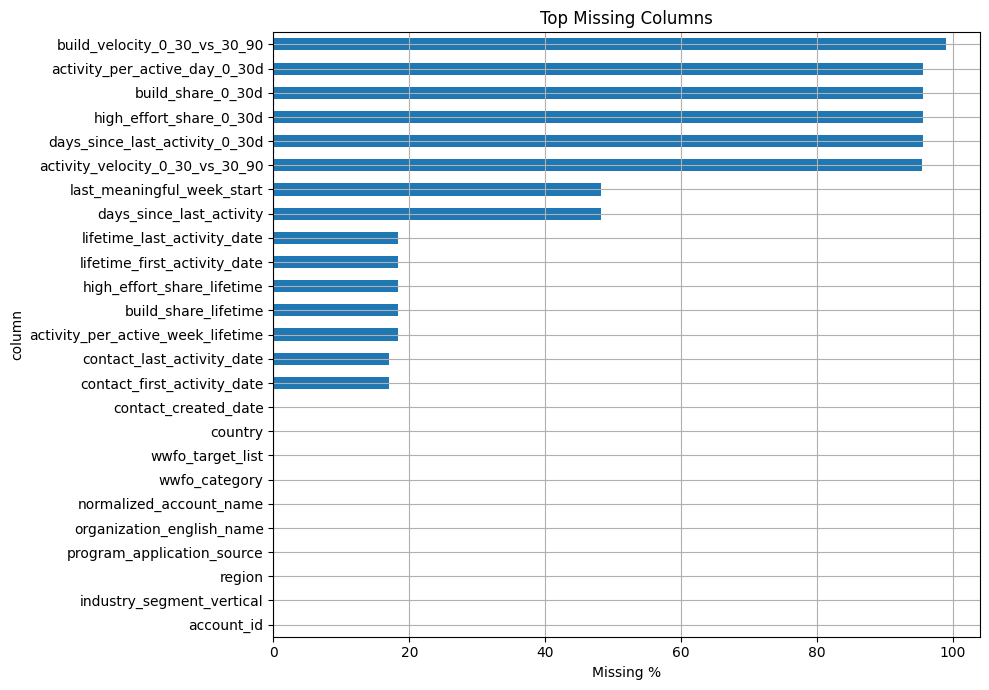

In [5]:
if 'developer_id' in df.columns:
    print(f"Duplicate developer_id rows: {df['developer_id'].duplicated().sum():,}")
missing=(df.isna().mean().mul(100).sort_values(ascending=False)
         .reset_index().rename(columns={'index':'column',0:'missing_pct'}))
display(missing.head(50))
plot_df=missing[missing['missing_pct']>0].head(25).sort_values('missing_pct')
if len(plot_df):
    ax=plot_df.plot.barh(x='column',y='missing_pct',figsize=(10,7),legend=False)
    ax.set_title('Top Missing Columns')
    ax.set_xlabel('Missing %')
    plt.tight_layout(); plt.show()

## 5. Final Feature Validation Checklist
**Source:** Dom validation checks, expanded for final production design.

In [6]:
checks=[]
def add_check(name, condition_count, severity='WARN'):
    checks.append({'check':name,'violations':int(condition_count),'severity':severity})

count_like=[c for c in df.columns if any(x in c for x in ['count','weeks','days_since'])]
for c in count_like:
    s=pd.to_numeric(df[c],errors='coerce')
    add_check(f'{c} has negative values',(s<0).sum(),'ERROR')
if {'build_count_0_30d','activity_count_0_30d'}.issubset(df.columns):
    add_check('build_count_0_30d > activity_count_0_30d',(df['build_count_0_30d'].fillna(0)>df['activity_count_0_30d'].fillna(0)).sum(),'ERROR')
if {'high_effort_count_0_30d','activity_count_0_30d'}.issubset(df.columns):
    add_check('high_effort_count_0_30d > activity_count_0_30d',(df['high_effort_count_0_30d'].fillna(0)>df['activity_count_0_30d'].fillna(0)).sum(),'ERROR')
if {'dormancy_status','activity_count_0_30d'}.issubset(df.columns):
    add_check('Dormant users with recent activity > 0',((df['dormancy_status']=='Dormant')&(df['activity_count_0_30d'].fillna(0)>0)).sum(),'ERROR')
if {'behavior_journey_stage_30d','lifetime_activity_count'}.issubset(df.columns):
    add_check('Unactivated behavior users with lifetime_activity_count > 0',((df['behavior_journey_stage_30d']=='Unactivated')&(df['lifetime_activity_count'].fillna(0)>0)).sum(),'ERROR')
if 'developer_id' in df.columns:
    add_check('Duplicate developer_id rows in EDA dataframe',df['developer_id'].duplicated().sum(),'ERROR')
if 'persona_confidence' in df.columns:
    add_check('persona_confidence outside [0,1]',((df['persona_confidence']<0)|(df['persona_confidence']>1)).sum(),'ERROR')
if 'persona_entropy' in df.columns:
    add_check('persona_entropy outside [0,1]',((df['persona_entropy']<-0.000001)|(df['persona_entropy']>1.000001)).sum(),'ERROR')
checks_df=pd.DataFrame(checks).sort_values(['severity','violations'],ascending=[True,False])
display(checks_df)
if len(checks_df[(checks_df['severity']=='ERROR')&(checks_df['violations']>0)]):
    print('ERROR: Fix validation violations before modeling.')
else:
    print('All ERROR-level validation checks passed.')

,check,violations,severity
0,lifetime_meaningful_weeks has negative values,0,ERROR
1,days_since_last_activity has negative values,0,ERROR
2,activity_count_0_30d has negative values,0,ERROR
3,activity_count_30_90d has negative values,0,ERROR
4,activity_count_90_180d has negative values,0,ERROR
5,log_activity_count_0_30d has negative values,0,ERROR
6,log_activity_count_30_90d has negative values,0,ERROR
7,log_activity_count_90_180d has negative values,0,ERROR
8,build_count_0_30d has negative values,0,ERROR
9,build_count_30_90d has negative values,0,ERROR


All ERROR-level validation checks passed.


## 6. Population Overview: Activation and Dormancy
**Source:** Tyler population overview + Dom dormancy analysis.

,is_activated,developers,pct
0,1,7660278,81.65295
1,0,1721230,18.34705


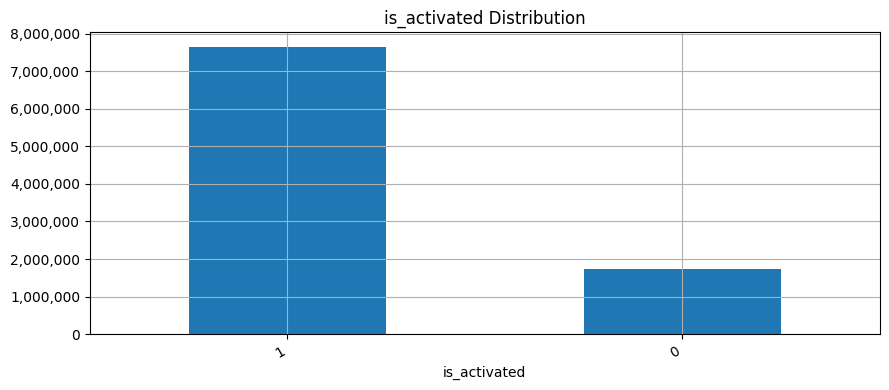

,dormancy_status,developers,pct
0,Dormant,5304852,56.545835
1,Unactivated,1721230,18.347050
2,At_Risk,1580877,16.850990
3,Active,418049,4.456096
4,Cooling,356500,3.800029


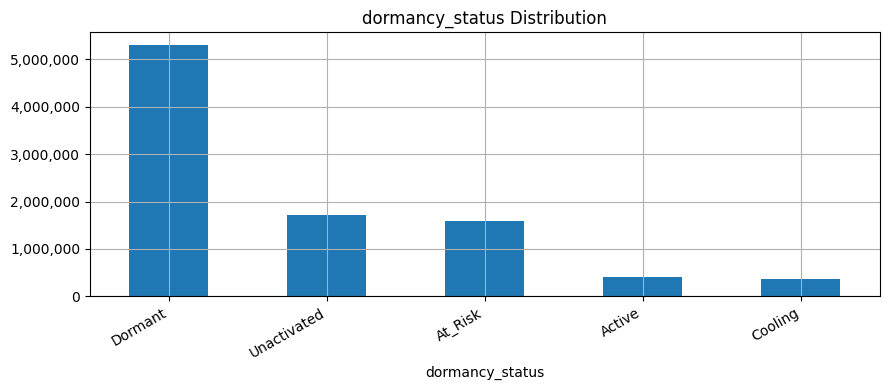

,dormant_flag,developers,pct
0,1,5304852,56.545835
1,0,4076656,43.454165


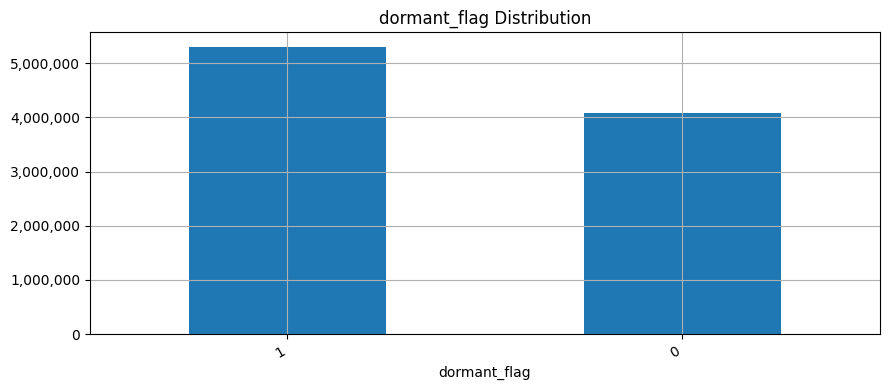

,at_risk_flag,developers,pct
0,0,7800631,83.14901
1,1,1580877,16.85099


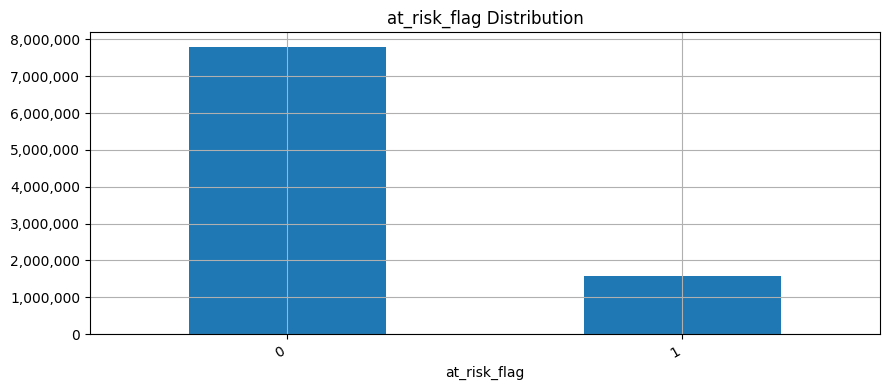

,dormancy_status,developers,median_days_since_last_activity,mean_days_since_last_activity,median_activity_0_30d,mean_activity_0_30d,pct
3,Dormant,5304852,1123.0,1206.891733,0.0,0.00000,56.545835
4,Unactivated,1721230,<NA>,<NA>,0.0,0.00000,18.347050
1,At_Risk,1580877,248.0,278.209169,0.0,0.00000,16.850990
0,Active,418049,10.0,35.046828,1.0,7.64049,4.456096
2,Cooling,356500,59.0,104.299126,0.0,0.00000,3.800029


In [7]:
for col in ['is_activated','dormancy_status','dormant_flag','at_risk_flag','cooling_flag']:
    if col in df.columns:
        out=df[col].value_counts(dropna=False).rename_axis(col).reset_index(name='developers')
        out['pct']=100*out['developers']/len(df)
        display(out)
        ax=out.plot.bar(x=col,y='developers',legend=False,figsize=(9,4))
        ax.set_title(f'{col} Distribution')
        ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
        plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()

if {'dormancy_status','days_since_last_activity'}.issubset(df.columns):
    agg_cols={'developers':('developer_id','count'), 'median_days_since_last_activity':('days_since_last_activity','median'), 'mean_days_since_last_activity':('days_since_last_activity','mean')}
    if 'activity_count_0_30d' in df.columns:
        agg_cols.update({'median_activity_0_30d':('activity_count_0_30d','median'), 'mean_activity_0_30d':('activity_count_0_30d','mean')})
    dorm_metrics=df.groupby('dormancy_status',dropna=False).agg(**agg_cols).reset_index()
    dorm_metrics['pct']=100*dorm_metrics['developers']/len(df)
    display(dorm_metrics.sort_values('developers',ascending=False))

## 7. Activity Distributions and Zero Inflation
**Source:** Tyler zero-vs-nonzero activity EDA + Dom distribution sanity checks.

,feature,zero_pct,nonzero_pct,mean,median,p90,p95,p99,max
0,activity_count_0_30d,95.54,4.46,0.340468,0.0,0.0,0.0,4.0,144228.0
1,activity_count_30_90d,95.47,4.53,0.378779,0.0,0.0,0.0,3.0,272221.0
2,activity_count_90_180d,94.45,5.55,0.404470,0.0,0.0,1.0,3.0,354569.0
3,lifetime_activity_count,18.35,81.65,7.391935,2.0,7.0,15.0,115.0,2027375.0
4,build_count_0_30d,99.52,0.48,0.062763,0.0,0.0,0.0,0.0,144228.0
5,lifetime_build_count,68.16,31.84,3.932019,0.0,2.0,5.0,76.0,2027374.0


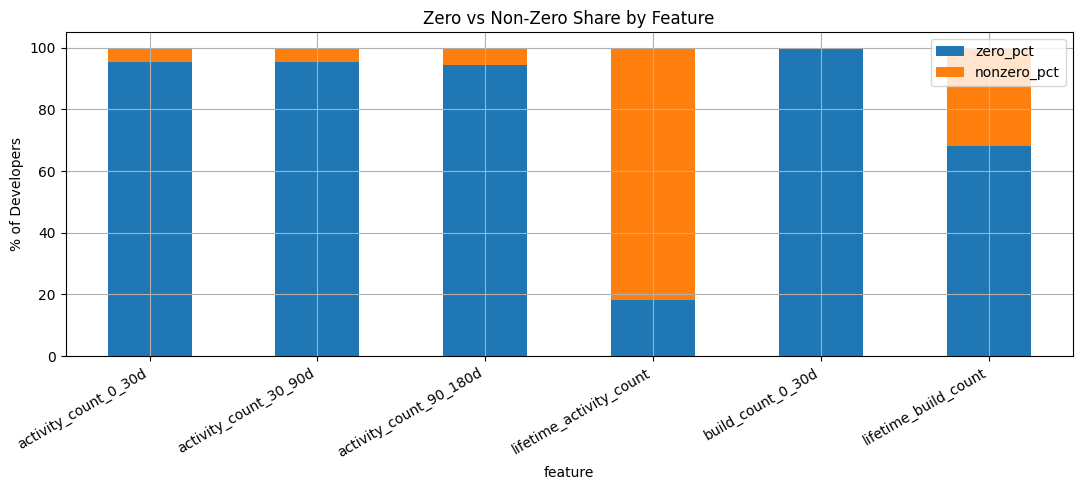

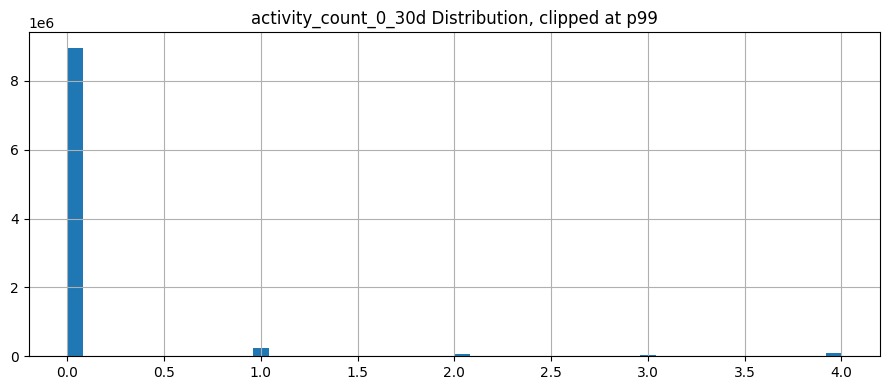

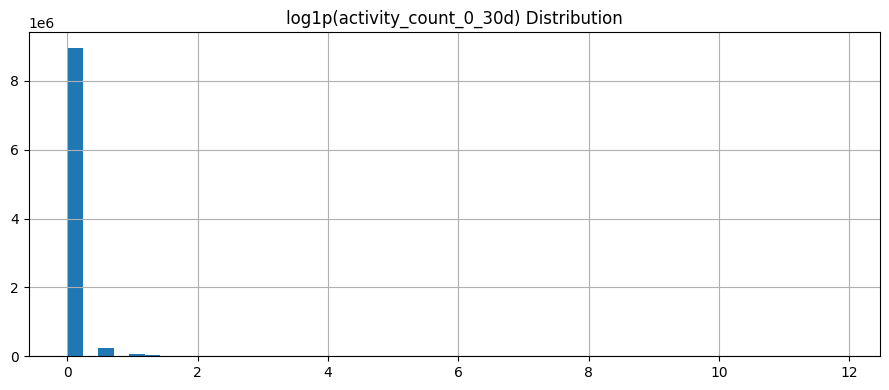

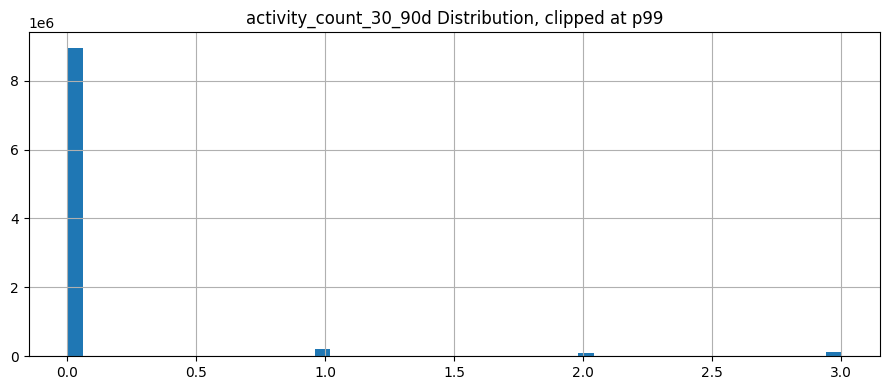

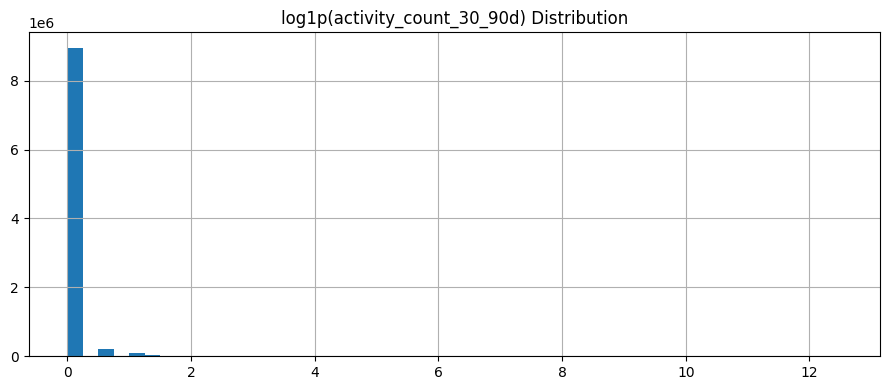

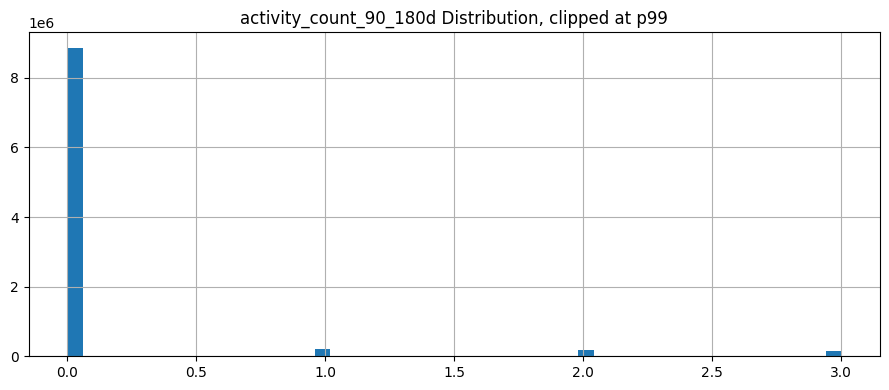

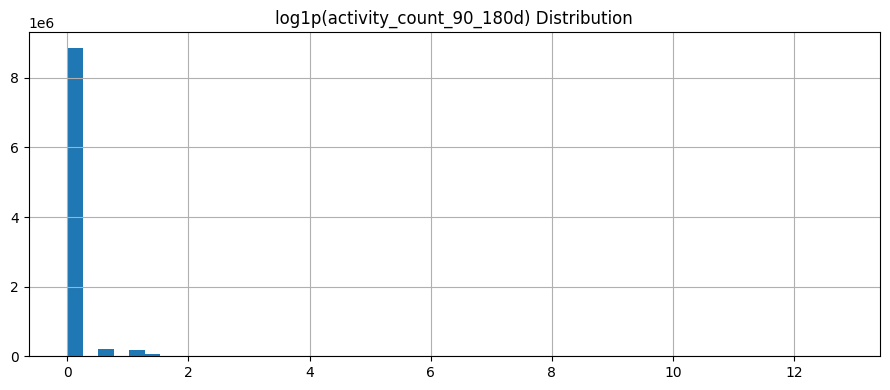

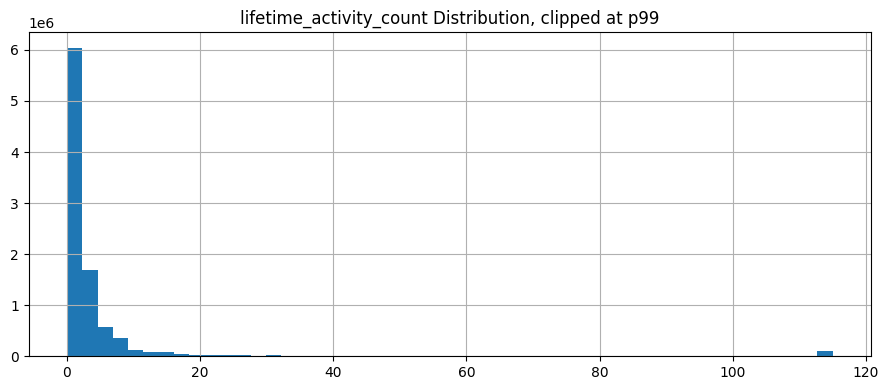

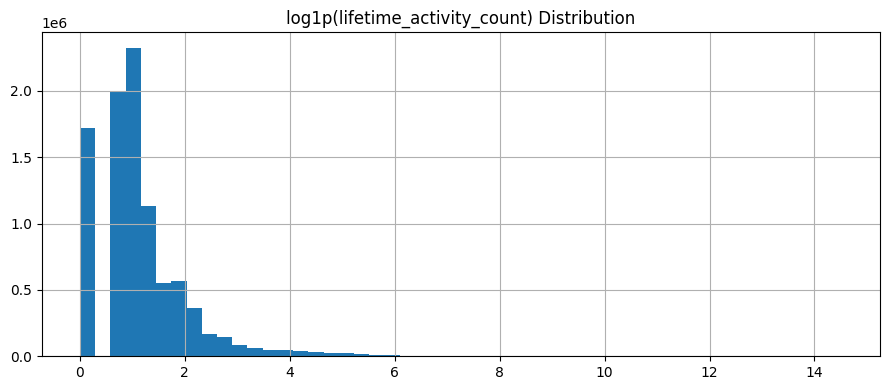

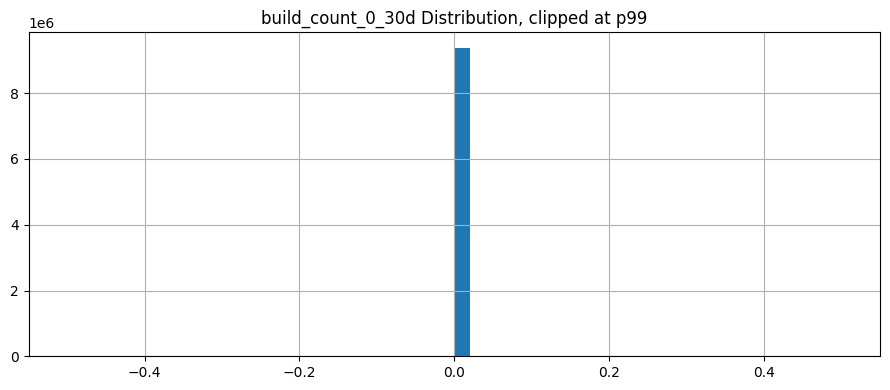

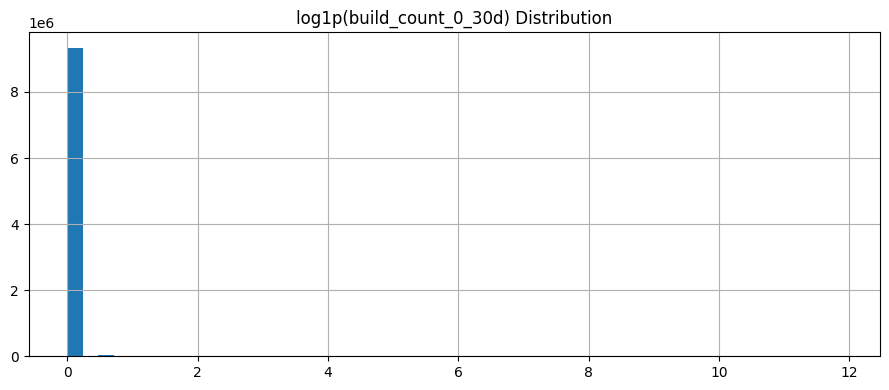

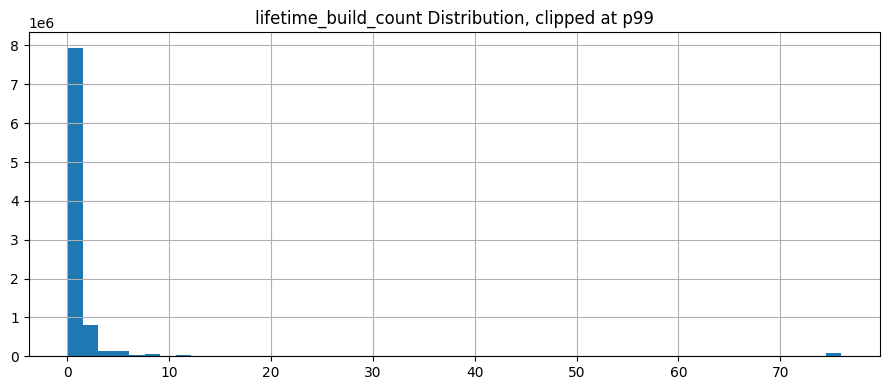

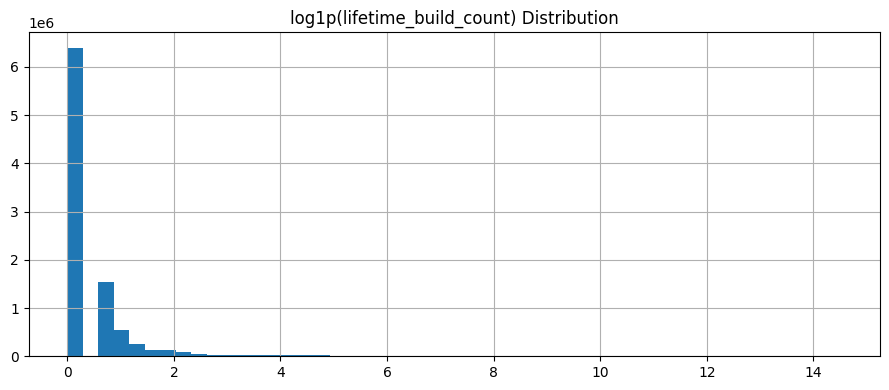

In [8]:
activity_cols=[c for c in ['activity_count_0_30d','activity_count_30_90d','activity_count_90_180d','lifetime_activity_count','build_count_0_30d','lifetime_build_count'] if c in df.columns]
rows=[]
for col in activity_cols:
    s=pd.to_numeric(df[col],errors='coerce').fillna(0)
    rows.append({'feature':col,'zero_pct':round(100*(s==0).mean(),2),'nonzero_pct':round(100*(s>0).mean(),2),'mean':s.mean(),'median':s.median(),'p90':s.quantile(.90),'p95':s.quantile(.95),'p99':s.quantile(.99),'max':s.max()})
activity_summary=pd.DataFrame(rows); display(activity_summary)
if len(activity_summary):
    ax=activity_summary.set_index('feature')[['zero_pct','nonzero_pct']].plot(kind='bar',stacked=True,figsize=(11,5))
    ax.set_title('Zero vs Non-Zero Share by Feature'); ax.set_ylabel('% of Developers')
    plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()
for col in activity_cols:
    s=pd.to_numeric(df[col],errors='coerce').fillna(0)
    plt.figure(figsize=(9,4)); s.clip(upper=s.quantile(.99)).hist(bins=50); plt.title(f'{col} Distribution, clipped at p99'); plt.tight_layout(); plt.show()
    plt.figure(figsize=(9,4)); np.log1p(s).hist(bins=50); plt.title(f'log1p({col}) Distribution'); plt.tight_layout(); plt.show()

## 8. Multi-Window Coverage Summary
**Source:** Tyler distribution-window EDA + new final-production validation.

This section checks all non-overlapping windows together. The 0-30 day window is the current-state lens, but the 30-90 and 90-180 day windows are needed to detect retention, reactivation, decline, and historical engagement.

,feature_group,window,nonzero_developers,nonzero_pct,mean,median,p90,p99,max
0,activity,activity_count_0_30d,418049,4.46,0.340468,0.0,0.0,4.0,144228.0
1,activity,activity_count_30_90d,425272,4.53,0.378779,0.0,0.0,3.0,272221.0
2,activity,activity_count_90_180d,520752,5.55,0.404470,0.0,0.0,3.0,354569.0
3,build,build_count_0_30d,45068,0.48,0.062763,0.0,0.0,0.0,144228.0
4,build,build_count_30_90d,91428,0.97,0.122013,0.0,0.0,0.0,272221.0
5,build,build_count_90_180d,165364,1.76,0.189253,0.0,0.0,1.0,354569.0
6,high_effort,high_effort_count_0_30d,46958,0.50,0.063574,0.0,0.0,0.0,144228.0
7,high_effort,high_effort_count_30_90d,94651,1.01,0.123857,0.0,0.0,1.0,272221.0
8,high_effort,high_effort_count_90_180d,170633,1.82,0.192748,0.0,0.0,1.0,354569.0


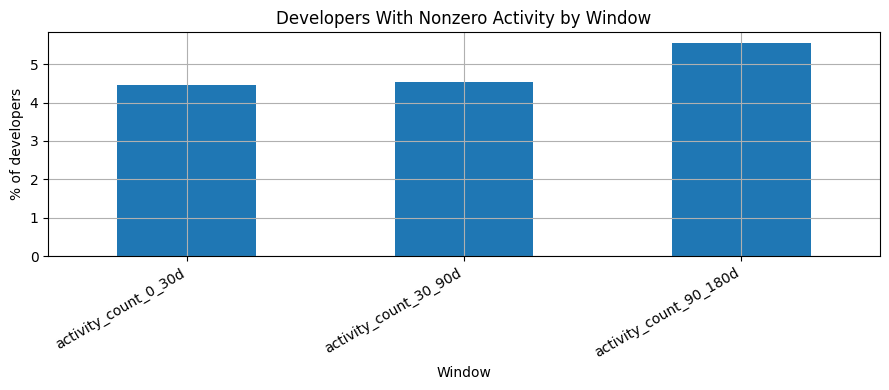

In [9]:
window_cols = [c for c in ['activity_count_0_30d','activity_count_30_90d','activity_count_90_180d'] if c in df.columns]
build_window_cols = [c for c in ['build_count_0_30d','build_count_30_90d','build_count_90_180d'] if c in df.columns]
effort_window_cols = [c for c in ['high_effort_count_0_30d','high_effort_count_30_90d','high_effort_count_90_180d'] if c in df.columns]

summary_rows = []
for label, cols_ in [('activity', window_cols), ('build', build_window_cols), ('high_effort', effort_window_cols)]:
    for c in cols_:
        s = pd.to_numeric(df[c], errors='coerce').fillna(0)
        summary_rows.append({
            'feature_group': label,
            'window': c,
            'nonzero_developers': int((s > 0).sum()),
            'nonzero_pct': round(100 * (s > 0).mean(), 2),
            'mean': s.mean(),
            'median': s.median(),
            'p90': s.quantile(0.90),
            'p99': s.quantile(0.99),
            'max': s.max()
        })
window_summary = pd.DataFrame(summary_rows)
display(window_summary)

if len(window_summary):
    plot_df = window_summary[window_summary['feature_group'].eq('activity')].copy()
    if len(plot_df):
        ax = plot_df.plot.bar(x='window', y='nonzero_pct', legend=False, figsize=(9,4))
        ax.set_title('Developers With Nonzero Activity by Window')
        ax.set_ylabel('% of developers')
        ax.set_xlabel('Window')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

## 9. Multi-Window Activity and Build Comparison
**Source:** Tyler histogram/percentile style, expanded to all final time windows.

These visuals show why 30 days should not be the only lens: current activity is sparse, while older windows reveal recent history and possible decline/reactivation.

,mean,median
activity_count_0_30d,0.340468,0.0
activity_count_30_90d,0.378779,0.0
activity_count_90_180d,0.404470,0.0


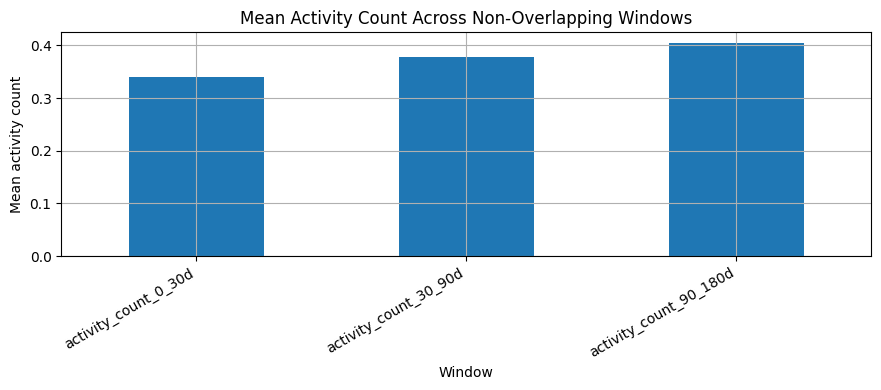

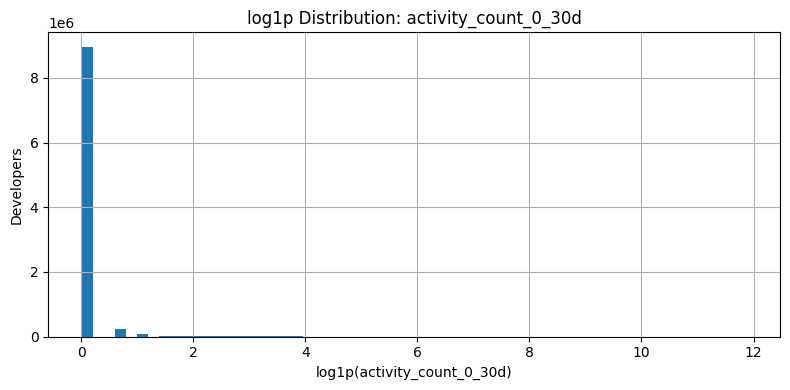

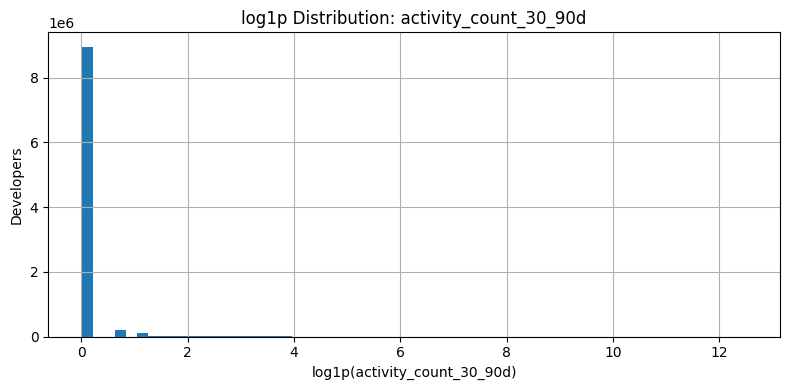

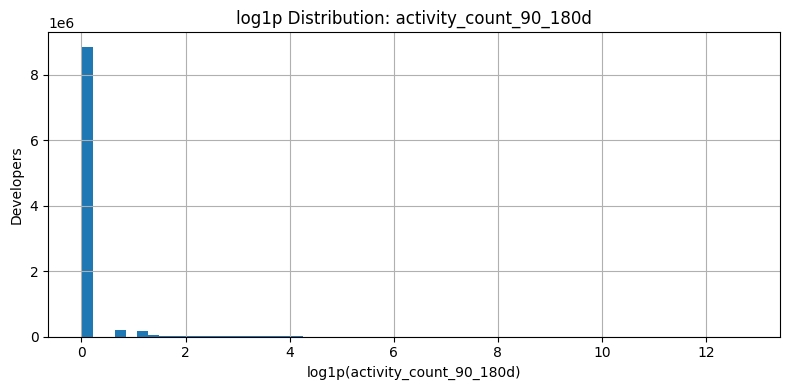

,mean_build_count
build_count_0_30d,0.062763
build_count_30_90d,0.122013
build_count_90_180d,0.189253


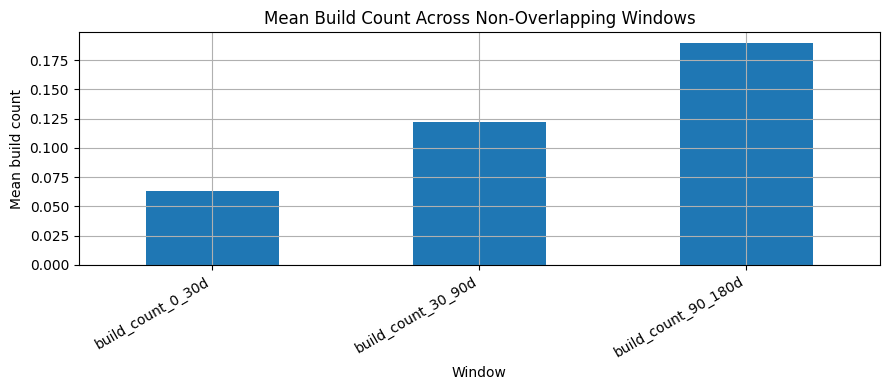

In [10]:
if window_cols:
    # Mean and median activity by window.
    means = df[window_cols].apply(pd.to_numeric, errors='coerce').fillna(0).mean()
    medians = df[window_cols].apply(pd.to_numeric, errors='coerce').fillna(0).median()
    comp = pd.DataFrame({'mean': means, 'median': medians})
    display(comp)
    ax = comp['mean'].plot(kind='bar', figsize=(9,4))
    ax.set_title('Mean Activity Count Across Non-Overlapping Windows')
    ax.set_ylabel('Mean activity count')
    ax.set_xlabel('Window')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

    # Log distributions by window.
    for col in window_cols:
        s = pd.to_numeric(df[col], errors='coerce').fillna(0)
        plt.figure(figsize=(8,4))
        np.log1p(s).hist(bins=60)
        plt.title(f'log1p Distribution: {col}')
        plt.xlabel(f'log1p({col})')
        plt.ylabel('Developers')
        plt.tight_layout()
        plt.show()

if build_window_cols:
    build_comp = df[build_window_cols].apply(pd.to_numeric, errors='coerce').fillna(0).mean().to_frame('mean_build_count')
    display(build_comp)
    ax = build_comp.plot(kind='bar', legend=False, figsize=(9,4))
    ax.set_title('Mean Build Count Across Non-Overlapping Windows')
    ax.set_ylabel('Mean build count')
    ax.set_xlabel('Window')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## 10. Window Participation Patterns
**Source:** New final-production EDA.

This creates compact behavioral patterns across 0-30, 30-90, and 90-180 days. It helps distinguish always-inactive developers from recently active, recently churned, reactivated, and consistently active developers.

,pattern,developers,pct
0,No activity in 180d,8150186,86.875010
1,Dormant after older activity,456773,4.868865
2,New / reactivated now,338870,3.612106
3,Recently churned,320877,3.420314
4,Active last 90d,50823,0.541736
5,Declining / cooling,35623,0.379715
6,Consistently active,17949,0.191323
7,Reactivated after gap,10407,0.110931


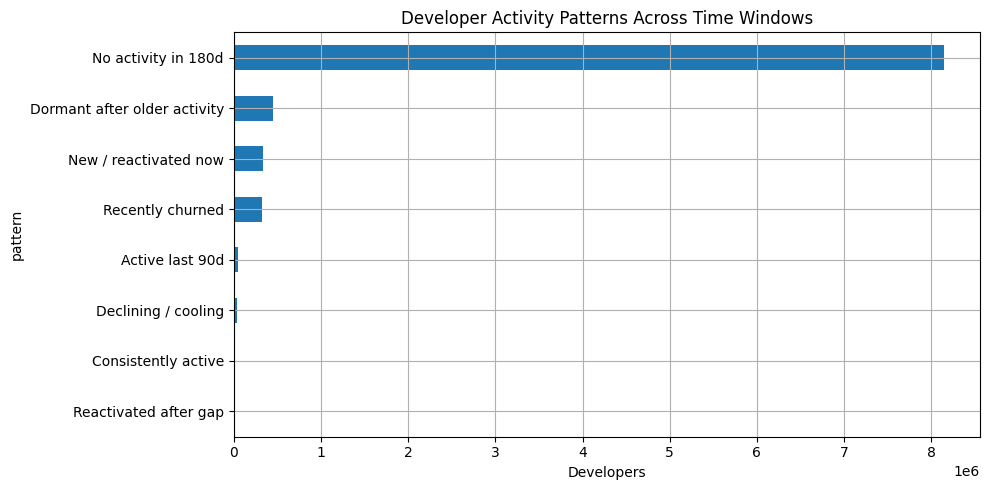

In [11]:
required = {'activity_count_0_30d','activity_count_30_90d','activity_count_90_180d'}
if required.issubset(df.columns):
    tmp = df.copy()
    tmp['active_0_30'] = pd.to_numeric(tmp['activity_count_0_30d'], errors='coerce').fillna(0) > 0
    tmp['active_30_90'] = pd.to_numeric(tmp['activity_count_30_90d'], errors='coerce').fillna(0) > 0
    tmp['active_90_180'] = pd.to_numeric(tmp['activity_count_90_180d'], errors='coerce').fillna(0) > 0
    tmp['activity_window_pattern'] = (
        tmp['active_90_180'].map({True:'1', False:'0'}) +
        tmp['active_30_90'].map({True:'1', False:'0'}) +
        tmp['active_0_30'].map({True:'1', False:'0'})
    )
    pattern_labels = {
        '000': 'No activity in 180d',
        '001': 'New / reactivated now',
        '010': 'Recently churned',
        '011': 'Active last 90d',
        '100': 'Dormant after older activity',
        '101': 'Reactivated after gap',
        '110': 'Declining / cooling',
        '111': 'Consistently active'
    }
    tmp['activity_window_pattern_label'] = tmp['activity_window_pattern'].map(pattern_labels)
    pattern = tmp['activity_window_pattern_label'].value_counts().rename_axis('pattern').reset_index(name='developers')
    pattern['pct'] = 100 * pattern['developers'] / len(tmp)
    display(pattern)
    ax = pattern.sort_values('developers').plot.barh(x='pattern', y='developers', legend=False, figsize=(10,5))
    ax.set_title('Developer Activity Patterns Across Time Windows')
    ax.set_xlabel('Developers')
    plt.tight_layout()
    plt.show()
else:
    print('Skipping window participation patterns: missing one or more activity window columns.')

## 11. Retention, Churn, and Reactivation Matrix
**Source:** New final-production EDA inspired by Dom's sanity-check style.

This explicitly answers: who was active before, who is active now, who churned, and who reactivated?

active_now_0_30,False,True,All
active_prior_30_90,,,
False,8606959,349277,8956236
True,356500,68772,425272
All,8963459,418049,9381508


active_now_0_30,False,True
active_prior_30_90,,
False,0.961,0.039
True,0.838,0.162


,status,developers,pct
0,Inactive both windows,8606959,91.743875
1,Recently churned,356500,3.800029
2,Reactivated / new active,349277,3.723037
3,Retained active,68772,0.733059


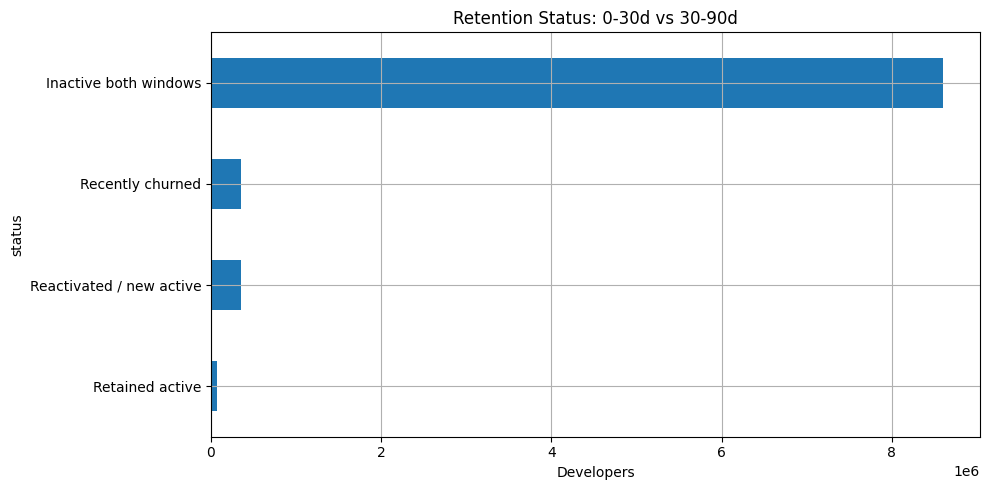

In [12]:
if {'activity_count_0_30d','activity_count_30_90d'}.issubset(df.columns):
    tmp = df.copy()
    tmp['active_now_0_30'] = pd.to_numeric(tmp['activity_count_0_30d'], errors='coerce').fillna(0) > 0
    tmp['active_prior_30_90'] = pd.to_numeric(tmp['activity_count_30_90d'], errors='coerce').fillna(0) > 0
    retention_matrix = pd.crosstab(tmp['active_prior_30_90'], tmp['active_now_0_30'], margins=True)
    retention_matrix_pct = pd.crosstab(tmp['active_prior_30_90'], tmp['active_now_0_30'], normalize='index')
    display(retention_matrix)
    display(retention_matrix_pct.round(3))

    tmp['retention_status_30_vs_90'] = np.select(
        [
            tmp['active_prior_30_90'] & tmp['active_now_0_30'],
            tmp['active_prior_30_90'] & ~tmp['active_now_0_30'],
            ~tmp['active_prior_30_90'] & tmp['active_now_0_30'],
            ~tmp['active_prior_30_90'] & ~tmp['active_now_0_30']
        ],
        ['Retained active', 'Recently churned', 'Reactivated / new active', 'Inactive both windows'],
        default='Unknown'
    )
    retention_status = tmp['retention_status_30_vs_90'].value_counts().rename_axis('status').reset_index(name='developers')
    retention_status['pct'] = 100 * retention_status['developers'] / len(tmp)
    display(retention_status)
    ax = retention_status.sort_values('developers').plot.barh(x='status', y='developers', legend=False, figsize=(10,5))
    ax.set_title('Retention Status: 0-30d vs 30-90d')
    ax.set_xlabel('Developers')
    plt.tight_layout()
    plt.show()
else:
    print('Skipping retention matrix: missing activity_count_0_30d or activity_count_30_90d.')

## 12. Velocity and Recency-Decay Validation
**Source:** New final-production EDA.

Velocity features should be used carefully. They are meaningful only when there is activity in at least one comparison window. This section validates acceleration, decline, and weighted recency features.

,count,mean,std,min,50%,90%,95%,99%,max
activity_velocity_0_30_vs_30_90,425272.0,0.479388,4.614399,0.0,0.0,0.545455,1.621109,9.000000,738.000000
build_velocity_0_30_vs_30_90,91428.0,0.274685,3.535522,0.0,0.0,0.000000,0.580645,3.063393,473.777778
weighted_recent_activity,9381508.0,0.358361,67.037581,0.0,0.0,0.200000,0.600000,4.800000,203660.000000


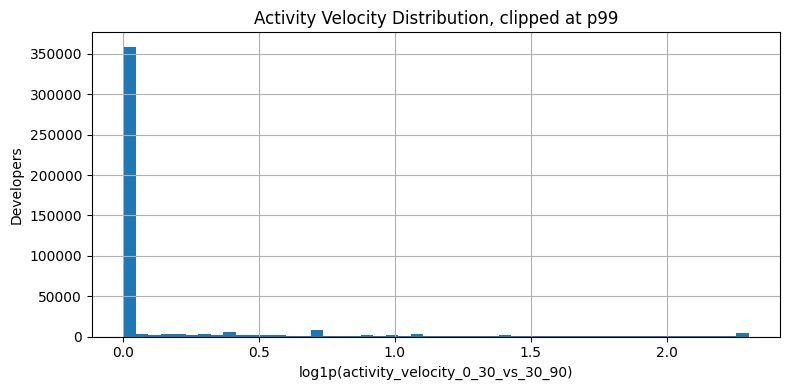

Skipping trend validation: missing trend_signal or window count columns.


In [13]:
velocity_cols = [c for c in ['activity_velocity_0_30_vs_30_90','build_velocity_0_30_vs_30_90','weighted_recent_activity','weighted_recent_builds'] if c in df.columns]
if velocity_cols:
    display(df[velocity_cols].describe(percentiles=[.5,.9,.95,.99]).T)

if 'activity_velocity_0_30_vs_30_90' in df.columns:
    v = pd.to_numeric(df['activity_velocity_0_30_vs_30_90'], errors='coerce')
    v_nonnull = v.replace([np.inf, -np.inf], np.nan).dropna()
    if len(v_nonnull):
        plt.figure(figsize=(8,4))
        np.log1p(v_nonnull.clip(lower=0, upper=v_nonnull.quantile(.99))).hist(bins=50)
        plt.title('Activity Velocity Distribution, clipped at p99')
        plt.xlabel('log1p(activity_velocity_0_30_vs_30_90)')
        plt.ylabel('Developers')
        plt.tight_layout()
        plt.show()

# Validate trend_signal against raw windows.
if {'trend_signal','activity_count_0_30d','activity_count_30_90d'}.issubset(df.columns):
    trend_validation = df.groupby('trend_signal', dropna=False)[['activity_count_0_30d','activity_count_30_90d']].agg(['count','mean','median'])
    display(trend_validation)
else:
    print('Skipping trend validation: missing trend_signal or window count columns.')

## 13. Behavior Stage Across All Time Windows
**Source:** New final-production EDA.

This validates whether behavior stages differ only in the current window or also show meaningful historical differences.

,activity_count_0_30d,activity_count_30_90d,activity_count_90_180d,build_count_0_30d,build_count_30_90d,build_count_90_180d,high_effort_count_0_30d,high_effort_count_30_90d,high_effort_count_90_180d,lifetime_activity_count,lifetime_build_count
behavior_journey_stage_30d,,,,,,,,,,,
Builder,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,52.0,39.0
Evaluator,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,8.0
Explorer,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0
Historically_Active,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0
Learner,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Unactivated,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


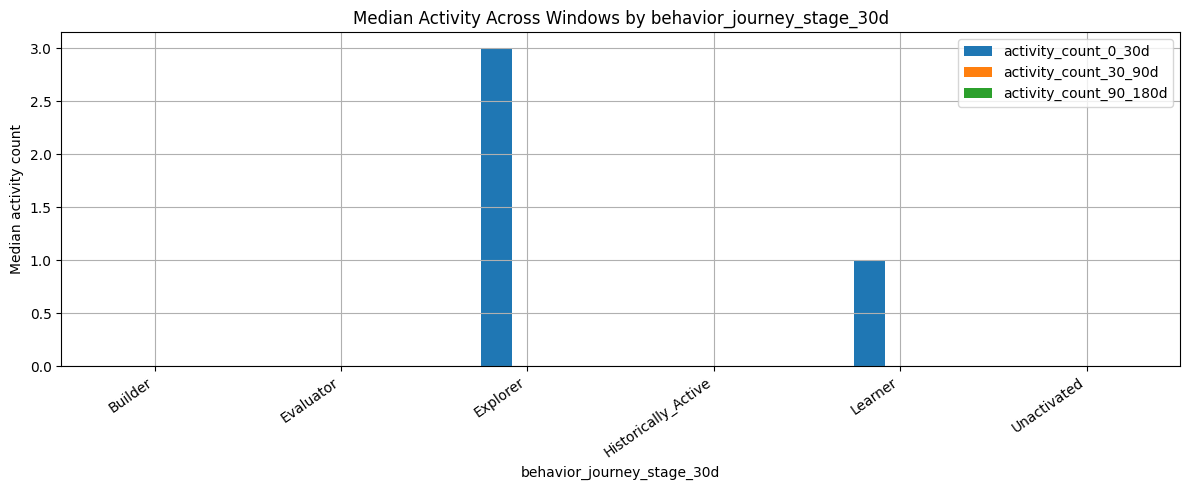

In [14]:
stage_col = 'behavior_journey_stage_30d' if 'behavior_journey_stage_30d' in df.columns else 'current_journey_state_30d'
metrics = [c for c in [
    'activity_count_0_30d','activity_count_30_90d','activity_count_90_180d',
    'build_count_0_30d','build_count_30_90d','build_count_90_180d',
    'high_effort_count_0_30d','high_effort_count_30_90d','high_effort_count_90_180d',
    'lifetime_activity_count','lifetime_build_count'
] if c in df.columns]

if stage_col in df.columns and metrics:
    stage_window_profile = df.groupby(stage_col)[metrics].median().round(3)
    display(stage_window_profile)
    plot_metrics = [c for c in ['activity_count_0_30d','activity_count_30_90d','activity_count_90_180d'] if c in metrics]
    if plot_metrics:
        plot_df = stage_window_profile[plot_metrics]
        ax = plot_df.plot(kind='bar', figsize=(12,5))
        ax.set_title(f'Median Activity Across Windows by {stage_col}')
        ax.set_ylabel('Median activity count')
        ax.set_xlabel(stage_col)
        plt.xticks(rotation=35, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print('Skipping behavior-stage multi-window profile: missing stage or metric columns.')

## 14. Persona and Lifecycle Across Time Windows
**Source:** Tyler persona diagnostics + new multi-window production EDA.

This shows which personas have current activity versus mostly historical activity, helping translate lifecycle findings into business segments.

activity_count_0_30d        activity_count_30_90d         \
                                   mean median                  mean median   
persona                                                                       
CUDA                              0.108    0.0                 0.178    0.0   
GenAI                             1.003    0.0                 0.865    0.0   
Learning_Community                0.054    0.0                 0.109    0.0   
Robotics                          0.675    0.0                 1.312    0.0   
Simulation                        0.040    0.0                 0.063    0.0   
Unknown                           0.023    0.0                 0.031    0.0   

                   activity_count_90_180d        lifetime_activity_count  \
                                     mean median                    mean   
persona                                                                    
CUDA                                0.259    0.0                   8.747   
GenAI                               0.646    0.0                   5.881   
Learning_Community                  0.159    0.0                   3.287   
Robotics                            2.018    0.0                  34.006   
Simulation                          0.098    0.0                   3.374   
Unknown                             0.030    0.0                   0.660   

                           
                   median  
persona                    
CUDA                  3.0  
GenAI                 1.0  
Learning_Community    2.0  
Robotics              3.0  
Simulation            2.0  
Unknown               0.0

,has_activity_0_30d,has_activity_30_90d,has_activity_90_180d
persona,,,
CUDA,1.65,3.15,5.47
GenAI,12.67,8.85,7.91
Learning_Community,2.11,5.23,6.91
Robotics,4.30,6.86,10.28
Simulation,1.50,2.28,2.96
Unknown,1.17,1.56,1.70


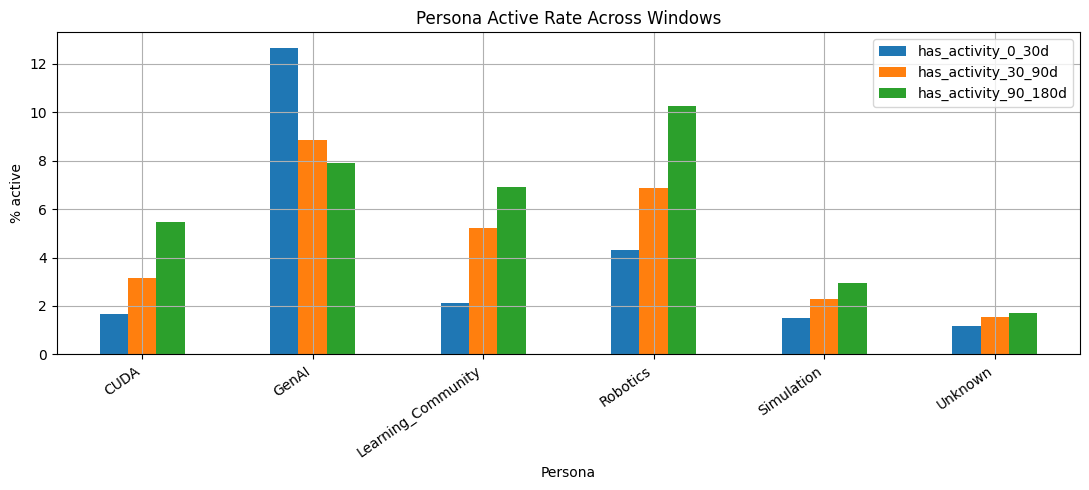

In [15]:
if 'persona' in df.columns and window_cols:
    persona_window = df.groupby('persona')[window_cols + [c for c in ['lifetime_activity_count'] if c in df.columns]].agg(['mean','median']).round(3)
    display(persona_window)

    persona_active_rates = df.groupby('persona')[[c for c in ['has_activity_0_30d','has_activity_30_90d','has_activity_90_180d'] if c in df.columns]].mean().mul(100).round(2)
    if not persona_active_rates.empty:
        display(persona_active_rates)
        ax = persona_active_rates.plot(kind='bar', figsize=(11,5))
        ax.set_title('Persona Active Rate Across Windows')
        ax.set_ylabel('% active')
        ax.set_xlabel('Persona')
        plt.xticks(rotation=35, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print('Skipping persona multi-window EDA: missing persona or activity window columns.')

## 15. Behavior Journey Stage Distribution
**Source:** Tyler journey-state distribution, updated for behavior-only final stage.

,behavior_journey_stage_30d,developers,pct
0,Historically_Active,6945840,74.037564
1,Unactivated,1721230,18.347050
2,Builder,320215,3.413257
3,Learner,269740,2.875231
4,Explorer,96094,1.024292
5,Evaluator,28389,0.302606


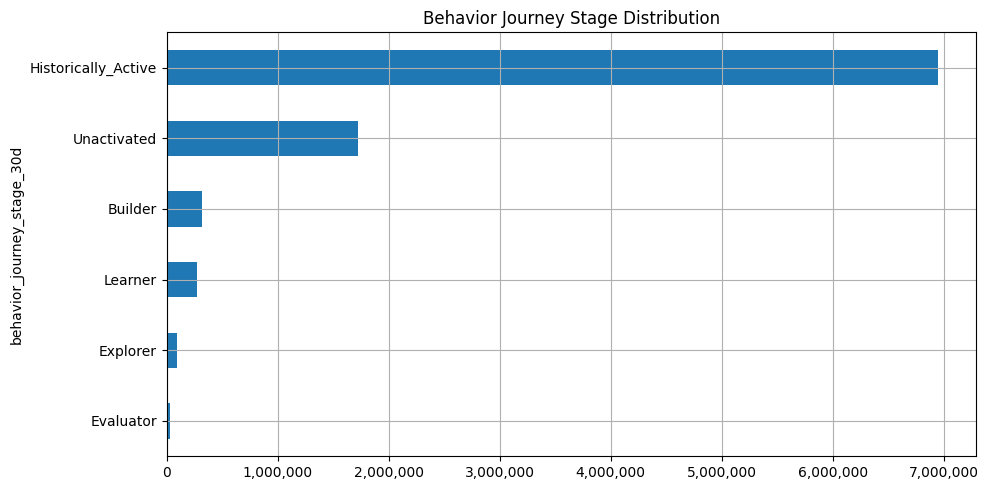

In [16]:
stage_col='behavior_journey_stage_30d' if 'behavior_journey_stage_30d' in df.columns else 'current_journey_state_30d'
stage_dist=df[stage_col].value_counts(dropna=False).rename_axis(stage_col).reset_index(name='developers')
stage_dist['pct']=100*stage_dist['developers']/len(df)
display(stage_dist)
ax=stage_dist.sort_values('developers').plot.barh(x=stage_col,y='developers',figsize=(10,5),legend=False)
ax.set_title('Behavior Journey Stage Distribution'); ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout(); plt.show()

## 16. Behavior Stage vs Lifecycle Heatmap
**Source:** New final validation inspired by Dom cross-tabs. This proves behavior and dormancy are separate dimensions.

dormancy_status,Active,At_Risk,Cooling,Dormant,Unactivated
behavior_journey_stage_30d,,,,,
Builder,50311,77295,24457,168152,0
Evaluator,1904,4801,1178,20506,0
Explorer,96094,0,0,0,0
Historically_Active,0,1498781,330865,5116194,0
Learner,269740,0,0,0,0
Unactivated,0,0,0,0,1721230


dormancy_status,Active,At_Risk,Cooling,Dormant,Unactivated
behavior_journey_stage_30d,,,,,
Builder,0.157,0.241,0.076,0.525,0.0
Evaluator,0.067,0.169,0.041,0.722,0.0
Explorer,1.000,0.000,0.000,0.000,0.0
Historically_Active,0.000,0.216,0.048,0.737,0.0
Learner,1.000,0.000,0.000,0.000,0.0
Unactivated,0.000,0.000,0.000,0.000,1.0


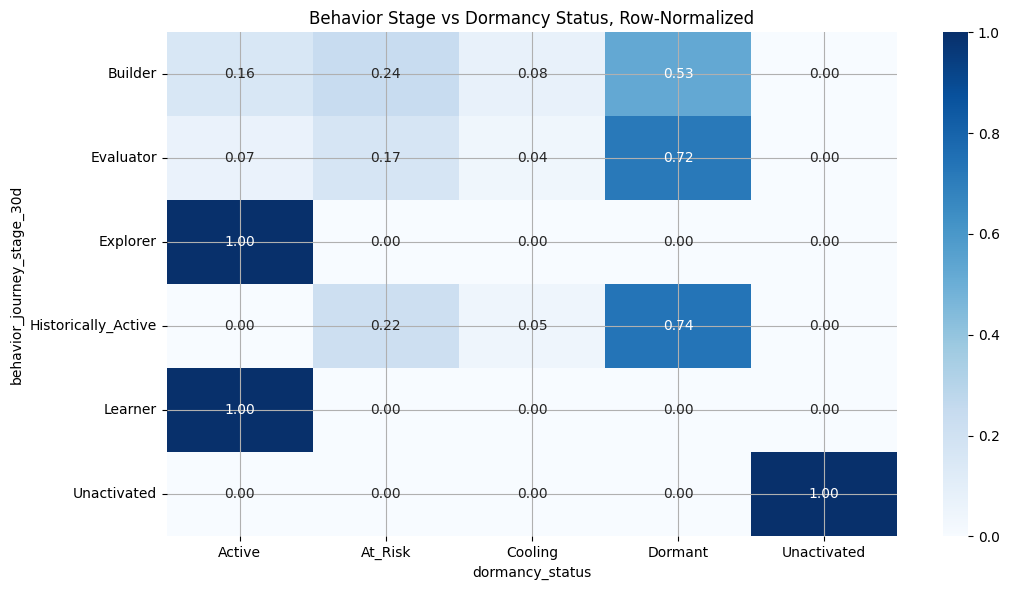

In [17]:
if {'behavior_journey_stage_30d','dormancy_status'}.issubset(df.columns):
    ct_counts=pd.crosstab(df['behavior_journey_stage_30d'],df['dormancy_status'])
    ct_norm=pd.crosstab(df['behavior_journey_stage_30d'],df['dormancy_status'],normalize='index')
    display(ct_counts); display(ct_norm.round(3))
    plt.figure(figsize=(11,6))
    if HAS_SEABORN:
        sns.heatmap(ct_norm,annot=True,fmt='.2f',cmap='Blues')
    else:
        plt.imshow(ct_norm.values,aspect='auto'); plt.xticks(range(len(ct_norm.columns)),ct_norm.columns,rotation=45,ha='right'); plt.yticks(range(len(ct_norm.index)),ct_norm.index); plt.colorbar(label='Row share')
    plt.title('Behavior Stage vs Dormancy Status, Row-Normalized')
    plt.tight_layout(); plt.show()

## 17. Combined Journey State Distribution
**Source:** New reporting view. Use for business storytelling, not as the primary modeling label.

,current_journey_state_30d,developers,pct
0,Dormant_Historically_Active,5116194,54.534879
1,Unactivated,1721230,18.347050
2,At_Risk_Historically_Active,1498781,15.975907
3,Cooling_Historically_Active,330865,3.526778
4,Learner,269740,2.875231
5,Dormant_Builder,168152,1.792377
6,Explorer,96094,1.024292
7,At_Risk_Builder,77295,0.823908
8,Builder,50311,0.536278
9,Cooling_Builder,24457,0.260694


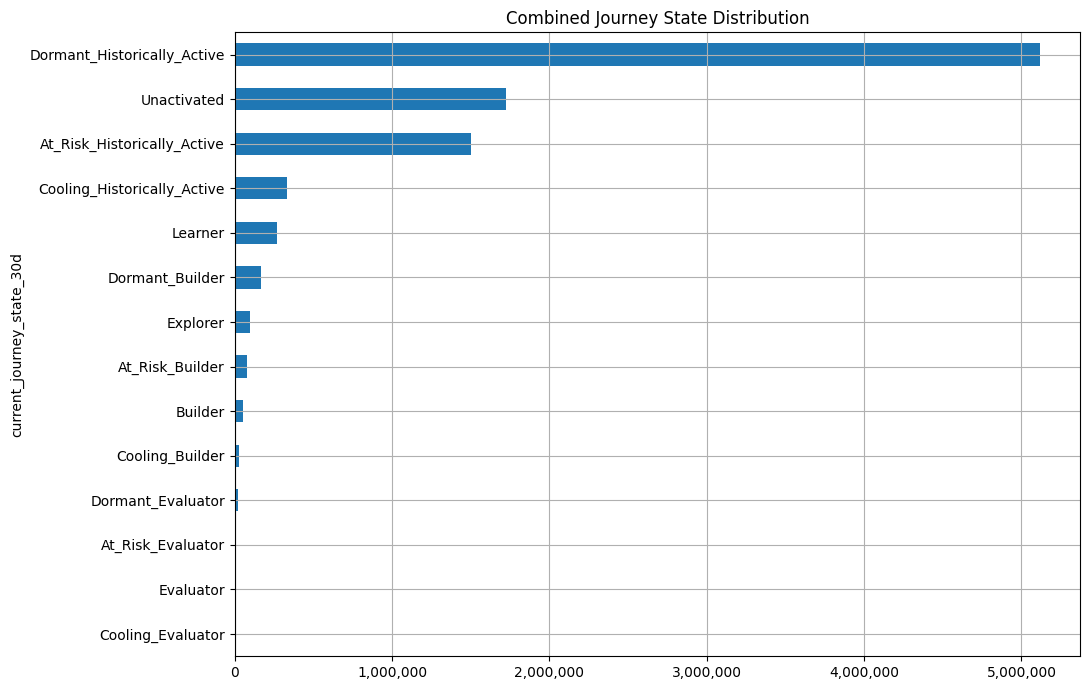

In [18]:
if 'current_journey_state_30d' in df.columns:
    combined=df['current_journey_state_30d'].value_counts(dropna=False).rename_axis('current_journey_state_30d').reset_index(name='developers')
    combined['pct']=100*combined['developers']/len(df)
    display(combined.head(30))
    ax=combined.head(20).sort_values('developers').plot.barh(x='current_journey_state_30d',y='developers',figsize=(11,7),legend=False)
    ax.set_title('Combined Journey State Distribution'); ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    plt.tight_layout(); plt.show()

## 18. Behavior Separation Validation
**Source:** Dom feature distribution and score-decomposition sections. Confirms behavior stages are meaningfully different.

activity_count_0_30d                    \
                                          count       mean median   
behavior_journey_stage_30d                                          
Builder                                  320215   2.242515    0.0   
Evaluator                                 28389   0.350734    0.0   
Explorer                                  96094  10.379014    3.0   
Historically_Active                     6945840   0.000000    0.0   
Learner                                  269740   5.444851    1.0   
Unactivated                             1721230   0.000000    0.0   

                           activity_count_30_90d                   \
                                           count      mean median   
behavior_journey_stage_30d                                          
Builder                                   320215  3.888946    0.0   
Evaluator                                  28389  0.391243    0.0   
Explorer                                   96094  0.056185    0.0   
Historically_Active                      6945840  0.103505    0.0   
Learner                                   269740  5.830752    0.0   
Unactivated                              1721230  0.000000    0.0   

                           build_count_0_30d                   \
                                       count      mean median   
behavior_journey_stage_30d                                      
Builder                               320215  1.838793    0.0   
Evaluator                              28389  0.000000    0.0   
Explorer                               96094  0.000000    0.0   
Historically_Active                  6945840  0.000000    0.0   
Learner                               269740  0.000000    0.0   
Unactivated                          1721230  0.000000    0.0   

                           high_effort_count_0_30d                   \
                                             count      mean median   
behavior_journey_stage_30d                                            
Builder                                     320215  1.848005    0.0   
Evaluator                                    28389  0.164113    0.0   
Explorer                                     96094  0.000000    0.0   
Historically_Active                        6945840  0.000000    0.0   
Learner                                     269740  0.000000    0.0   
Unactivated                                1721230  0.000000    0.0   

                           unique_activity_types_0_30d                   \
                                                 count      mean median   
behavior_journey_stage_30d                                                
Builder                                         320215  0.240601    0.0   
Evaluator                                        28389  0.100497    0.0   
Explorer                                         96094  2.016931    2.0   
Historically_Active                            6945840  0.000000    0.0   
Learner                                         269740  1.000000    1.0   
Unactivated                                    1721230  0.000000    0.0   

                           unique_modalities_0_30d                   \
                                             count      mean median   
behavior_journey_stage_30d                                            
Builder                                     320215  0.234589    0.0   
Evaluator                                    28389  0.092959    0.0   
Explorer                                     96094  1.292287    1.0   
Historically_Active                        6945840  0.000000    0.0   
Learner                                     269740  1.000000    1.0   
Unactivated                                1721230  0.000000    0.0   

                           lifetime_activity_count                     \
                                             count        mean median   
behavior_journey_stage_30d                                              
Builder               

,activity_count_0_30d,activity_count_30_90d,build_count_0_30d,high_effort_count_0_30d,unique_activity_types_0_30d,unique_modalities_0_30d,lifetime_activity_count,lifetime_build_count,lifetime_champion_count,lifetime_high_effort_count
behavior_journey_stage_30d,,,,,,,,,,
Builder,0.0,0.0,0.0,0.0,0.0,0.0,52.0,39.0,0.0,40.0
Evaluator,0.0,0.0,0.0,0.0,0.0,0.0,18.0,8.0,0.0,10.0
Explorer,3.0,0.0,0.0,0.0,2.0,1.0,3.0,0.0,0.0,0.0
Historically_Active,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
Learner,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
Unactivated,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


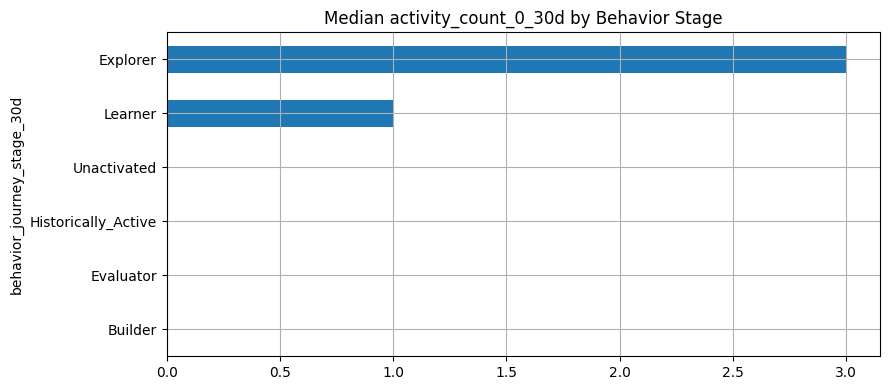

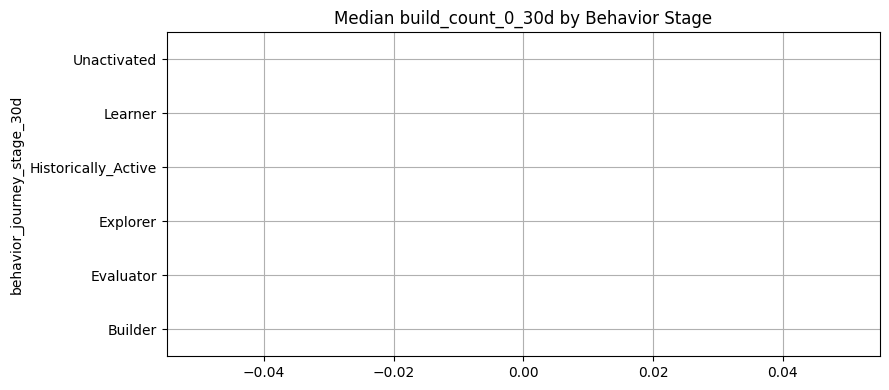

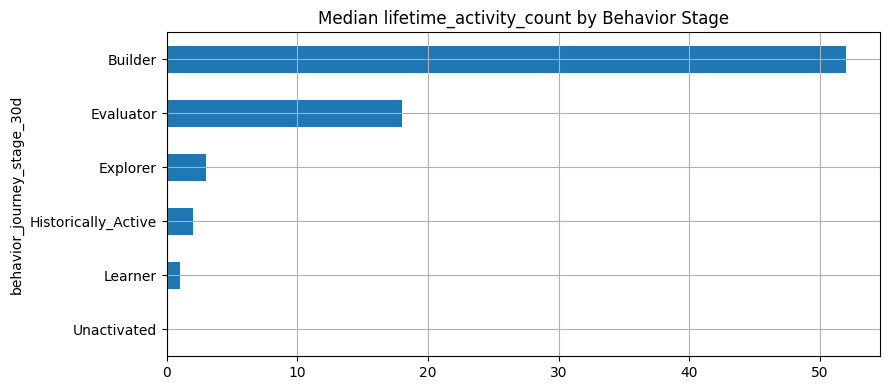

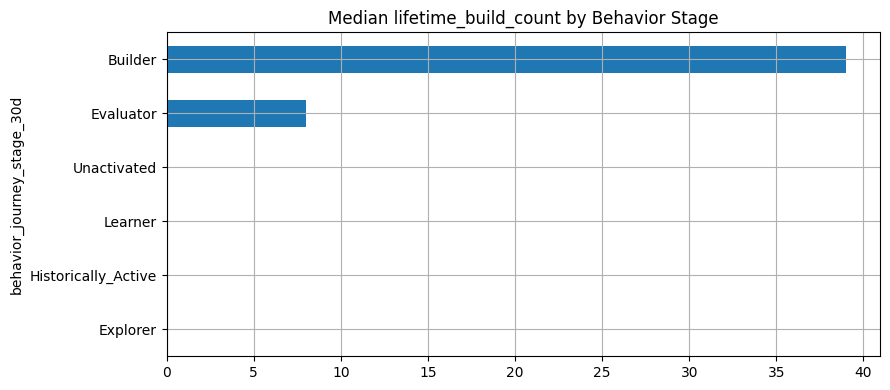

In [19]:
metric_cols=[c for c in ['activity_count_0_30d','activity_count_30_90d','build_count_0_30d','high_effort_count_0_30d','unique_activity_types_0_30d','unique_modalities_0_30d','lifetime_activity_count','lifetime_build_count','lifetime_champion_count','lifetime_high_effort_count'] if c in df.columns]
if stage_col in df.columns and metric_cols:
    display(df.groupby(stage_col,dropna=False)[metric_cols].agg(['count','mean','median']))
    medians=df.groupby(stage_col,dropna=False)[metric_cols].median()
    display(medians)
    for col in ['activity_count_0_30d','build_count_0_30d','lifetime_activity_count','lifetime_build_count']:
        if col in medians.columns:
            ax=medians[col].sort_values().plot(kind='barh',figsize=(9,4)); ax.set_title(f'Median {col} by Behavior Stage'); plt.tight_layout(); plt.show()

## 19. Business Insight: Builder Retention and Reactivation Opportunity
**Source:** New final-production business EDA.

Builders: 320,215


,dormancy_status,builders,pct_of_builders
0,Dormant,168152,52.512218
1,At_Risk,77295,24.138469
2,Active,50311,15.711631
3,Cooling,24457,7.637681


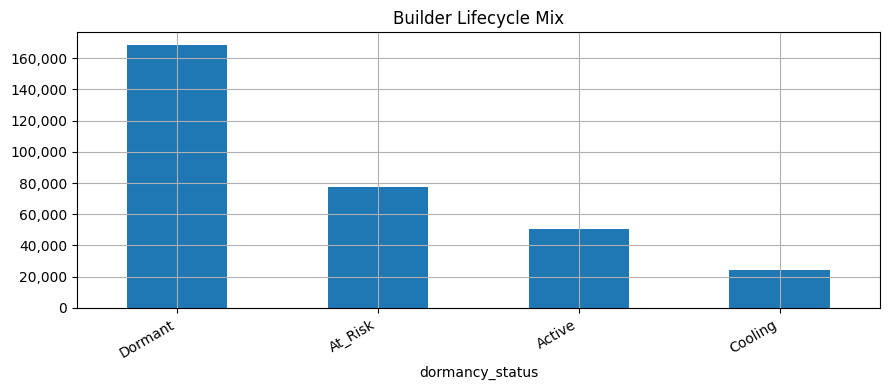

,count,mean,median,max
dormancy_status,,,,
Dormant,168152,82.870391,47.0,55060.0
At_Risk,77295,93.886034,42.0,107089.0
Active,50311,152.824074,3.0,2027374.0
Cooling,24457,111.458274,45.0,34322.0


In [20]:
if {'behavior_journey_stage_30d','dormancy_status'}.issubset(df.columns):
    builder_df=df[df['behavior_journey_stage_30d']=='Builder'].copy()
    print(f'Builders: {len(builder_df):,}')
    if len(builder_df):
        builder_dorm=builder_df['dormancy_status'].value_counts(dropna=False).rename_axis('dormancy_status').reset_index(name='builders')
        builder_dorm['pct_of_builders']=100*builder_dorm['builders']/len(builder_df)
        display(builder_dorm)
        ax=builder_dorm.plot.bar(x='dormancy_status',y='builders',figsize=(9,4),legend=False)
        ax.set_title('Builder Lifecycle Mix'); ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
        plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()
        if 'lifetime_build_count' in builder_df.columns:
            display(builder_df.groupby('dormancy_status')['lifetime_build_count'].agg(['count','mean','median','max']).sort_values('count',ascending=False))

## 20. Intent and Trend Validation
**Source:** Tyler flag/journey validation. Trend is intentionally missing for inactive developers.

In [21]:
if 'intent_signal' in df.columns:
    intent_metrics=[c for c in ['activity_count_0_30d','build_count_0_30d','high_effort_count_0_30d','lifetime_build_count','lifetime_high_effort_count'] if c in df.columns]
    display(df.groupby('intent_signal',dropna=False)[intent_metrics].agg(['count','mean','median']))
    intent_counts=df['intent_signal'].value_counts(dropna=False).rename_axis('intent_signal').reset_index(name='developers')
    intent_counts['pct']=100*intent_counts['developers']/len(df); display(intent_counts)
    ax=intent_counts.plot.bar(x='intent_signal',y='developers',figsize=(9,4),legend=False); ax.set_title('Intent Signal Distribution'); plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()
if 'trend_signal' in df.columns:
    trend_metrics=[c for c in ['activity_count_0_30d','activity_count_30_90d','recent_activity_trend_ratio'] if c in df.columns]
    display(df.groupby('trend_signal',dropna=False)[trend_metrics].agg(['count','mean','median']))
    trend_counts=df['trend_signal'].value_counts(dropna=False).rename_axis('trend_signal').reset_index(name='developers')
    trend_counts['pct']=100*trend_counts['developers']/len(df); display(trend_counts)
    ax=trend_counts.plot.bar(x='trend_signal',y='developers',figsize=(9,4),legend=False); ax.set_title('Trend Signal Distribution'); plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()

## 21. Persona Distribution and Confidence
**Source:** Tyler persona distribution + Dom confidence diagnostics.

,persona,developers,pct
0,CUDA,3519981,37.520418
1,GenAI,2314671,24.672697
2,Unknown,1869569,19.928235
3,Robotics,590804,6.297538
4,Simulation,570051,6.076326
5,Learning_Community,516432,5.504787


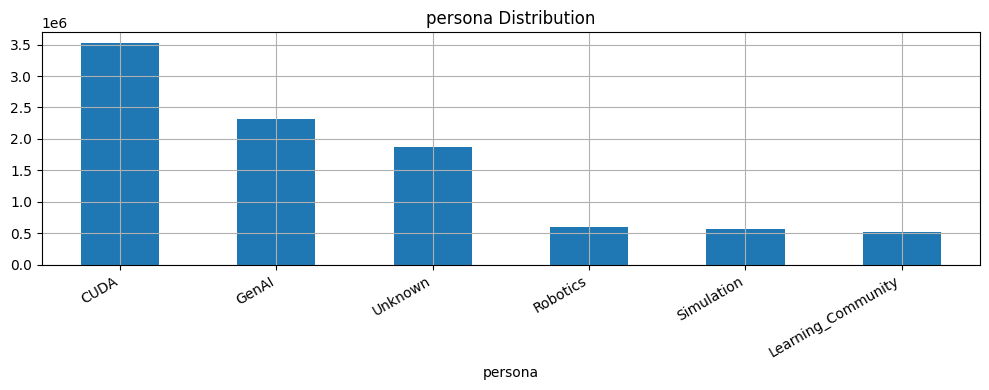

,persona_confidence_tier,developers,pct
0,High,4405858,46.963217
1,Medium,2393443,25.512348
2,Unknown,1869569,19.928235
3,Low,712638,7.596199


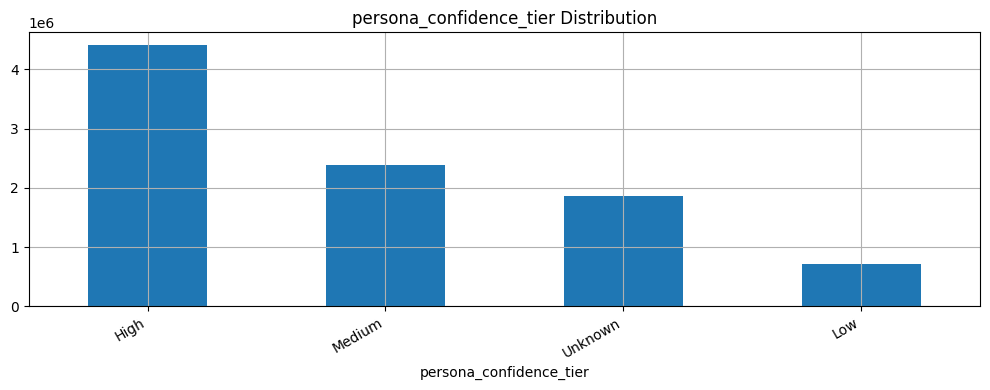

,mixed_persona_flag,developers,pct
0,0,7083718,75.507243
1,1,2297790,24.492757


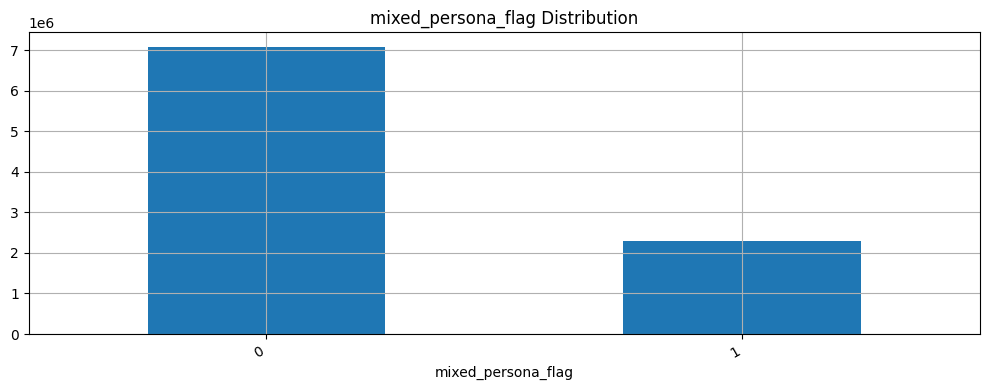

In [22]:
for col in ['persona','persona_confidence_tier','mixed_persona_flag']:
    if col in df.columns:
        out=df[col].value_counts(dropna=False).reset_index(name='developers')
        out['pct']=100*out['developers']/len(df)
        display(out.head(30))
        ax=out.head(20).plot.bar(x=col,y='developers',figsize=(10,4),legend=False); ax.set_title(f'{col} Distribution')
        plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()

## 22. Persona x Behavior x Lifecycle
**Source:** Tyler cross-segment persona breakdowns + Dom lane x journey cross-analysis.

behavior_journey_stage_30d,Builder,Evaluator,Explorer,Historically_Active,Learner,Unactivated
persona,,,,,,
CUDA,0.044,0.006,0.002,0.937,0.008,0.003
GenAI,0.009,0.001,0.033,0.745,0.090,0.123
Learning_Community,0.007,0.001,0.011,0.911,0.007,0.063
Robotics,0.225,0.005,0.006,0.678,0.012,0.074
Simulation,0.010,0.003,0.002,0.876,0.007,0.102
Unknown,0.002,0.000,0.001,0.296,0.009,0.692


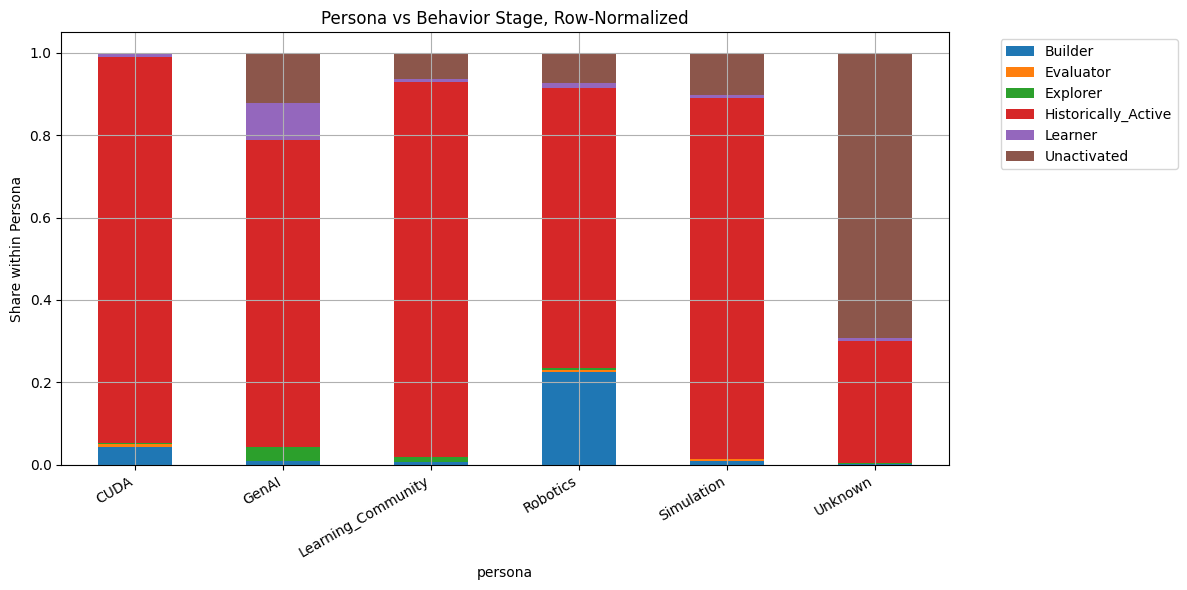

dormancy_status,Active,At_Risk,Cooling,Dormant,Unactivated
persona,,,,,
CUDA,0.016,0.183,0.029,0.769,0.003
GenAI,0.127,0.234,0.067,0.450,0.123
Learning_Community,0.021,0.205,0.050,0.662,0.063
Robotics,0.043,0.221,0.057,0.605,0.074
Simulation,0.015,0.088,0.021,0.774,0.102
Unknown,0.012,0.058,0.015,0.224,0.692


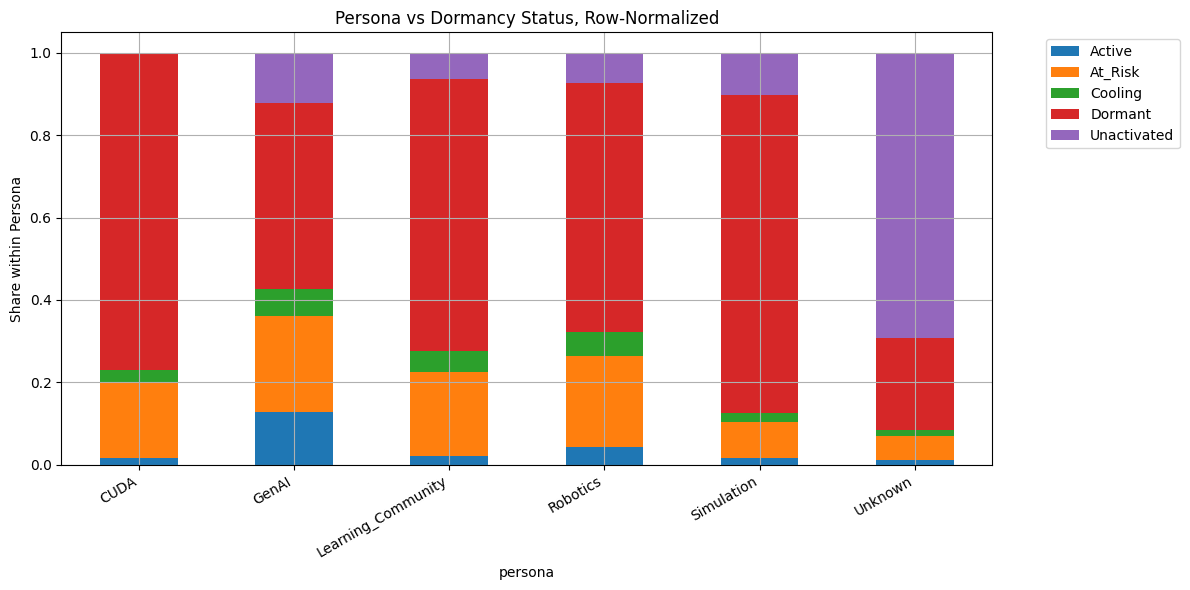

In [23]:
if {'persona','behavior_journey_stage_30d'}.issubset(df.columns):
    persona_behavior=pd.crosstab(df['persona'],df['behavior_journey_stage_30d'],normalize='index')
    display(persona_behavior.round(3))
    ax=persona_behavior.plot(kind='bar',stacked=True,figsize=(12,6)); ax.set_title('Persona vs Behavior Stage, Row-Normalized'); ax.set_ylabel('Share within Persona')
    plt.xticks(rotation=30,ha='right'); plt.legend(bbox_to_anchor=(1.05,1),loc='upper left'); plt.tight_layout(); plt.show()
if {'persona','dormancy_status'}.issubset(df.columns):
    persona_dorm=pd.crosstab(df['persona'],df['dormancy_status'],normalize='index')
    display(persona_dorm.round(3))
    ax=persona_dorm.plot(kind='bar',stacked=True,figsize=(12,6)); ax.set_title('Persona vs Dormancy Status, Row-Normalized'); ax.set_ylabel('Share within Persona')
    plt.xticks(rotation=30,ha='right'); plt.legend(bbox_to_anchor=(1.05,1),loc='upper left'); plt.tight_layout(); plt.show()

## 23. Lane Breadth and Cross-Lane Engagement
**Source:** Dom activity breadth and cadence.

In [24]:
lane_cols=[c for c in ['cuda_score','genai_score','robotics_score','simulation_score','learning_community_score'] if c in df.columns]
if lane_cols:
    lane_summary=[]
    for c in lane_cols:
        s=pd.to_numeric(df[c],errors='coerce').fillna(0)
        lane_summary.append({'lane':c,'nonzero_pct':100*(s>0).mean(),'mean':s.mean(),'p90':s.quantile(.90),'p99':s.quantile(.99),'max':s.max()})
    display(pd.DataFrame(lane_summary).sort_values('nonzero_pct',ascending=False))
    df['lane_breadth']=sum((pd.to_numeric(df[c],errors='coerce').fillna(0)>0).astype(int) for c in lane_cols)
    breadth=df['lane_breadth'].value_counts().sort_index().reset_index(name='developers')
    breadth.columns=['lane_breadth','developers']; breadth['pct']=100*breadth['developers']/len(df)
    display(breadth)
    ax=breadth.plot.bar(x='lane_breadth',y='developers',figsize=(8,4),legend=False); ax.set_title('Lane Breadth Distribution'); plt.tight_layout(); plt.show()
    if 'behavior_journey_stage_30d' in df.columns:
        display(df.groupby('behavior_journey_stage_30d')['lane_breadth'].agg(['count','mean','median']).sort_values('mean',ascending=False))

## 24. Correlation Analysis
**Source:** Tyler log-transformed correlation checks.

,activity_count_0_30d,activity_count_30_90d,activity_count_90_180d,build_count_0_30d,high_effort_count_0_30d,unique_activity_types_0_30d,unique_modalities_0_30d,lifetime_activity_count,lifetime_build_count,lifetime_champion_count,lifetime_high_effort_count,days_since_last_activity
activity_count_0_30d,1.000,0.350,0.121,0.399,0.404,0.820,0.790,0.226,0.018,0.019,0.010,-0.091
activity_count_30_90d,0.350,1.000,0.246,0.116,0.121,0.171,0.191,0.248,0.096,0.043,0.088,-0.043
activity_count_90_180d,0.121,0.246,1.000,0.101,0.105,0.049,0.058,0.246,0.170,0.068,0.160,-0.002
build_count_0_30d,0.399,0.116,0.101,1.000,0.989,0.266,0.291,0.131,0.177,0.032,0.169,-0.014
high_effort_count_0_30d,0.404,0.121,0.105,0.989,1.000,0.272,0.297,0.134,0.177,0.059,0.172,-0.014
unique_activity_types_0_30d,0.820,0.171,0.049,0.266,0.272,1.000,0.982,0.110,-0.024,0.011,-0.033,-0.125
unique_modalities_0_30d,0.790,0.191,0.058,0.291,0.297,0.982,1.000,0.103,-0.018,0.013,-0.027,-0.131
lifetime_activity_count,0.226,0.248,0.246,0.131,0.134,0.110,0.103,1.000,0.736,0.202,0.763,0.581
lifetime_build_count,0.018,0.096,0.170,0.177,0.177,-0.024,-0.018,0.736,1.000,0.173,0.975,0.445
lifetime_champion_count,0.019,0.043,0.068,0.032,0.059,0.011,0.013,0.202,0.173,1.000,0.245,0.047


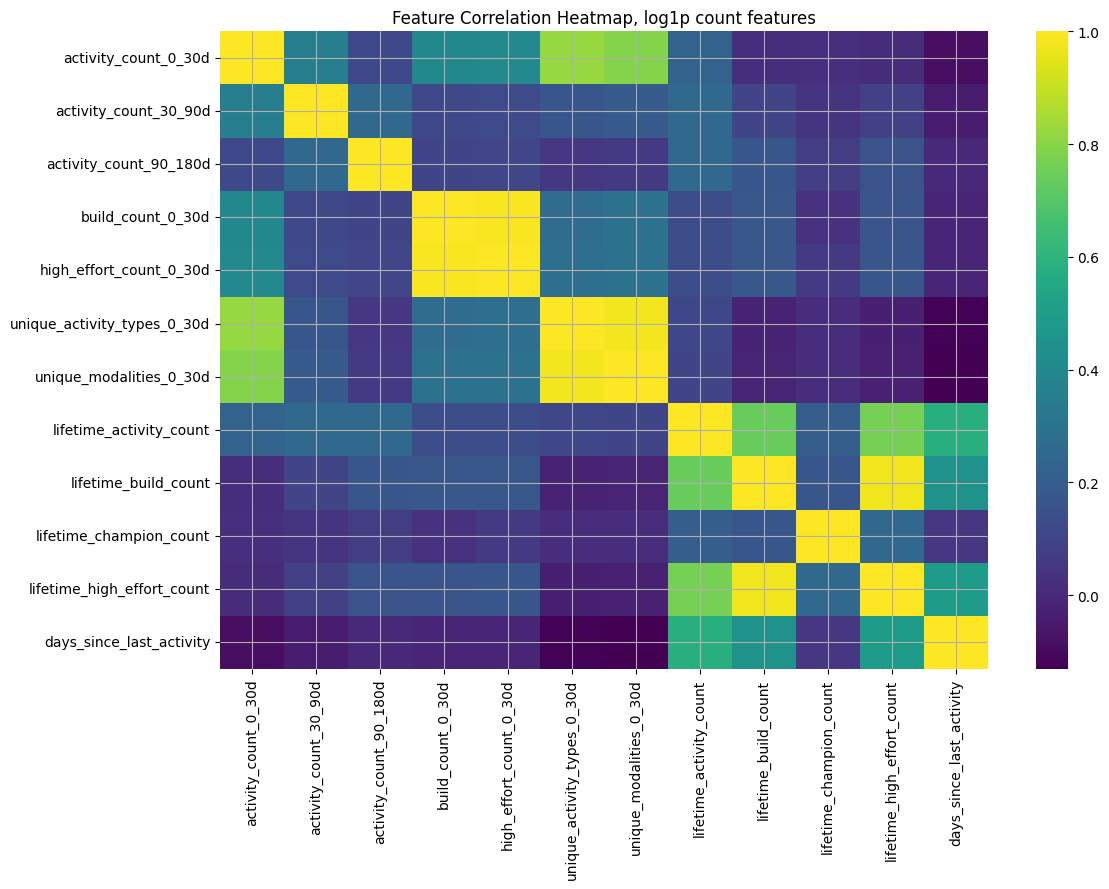

In [25]:
corr_cols=[c for c in ['activity_count_0_30d','activity_count_30_90d','activity_count_90_180d','build_count_0_30d','high_effort_count_0_30d','unique_activity_types_0_30d','unique_modalities_0_30d','lifetime_activity_count','lifetime_build_count','lifetime_champion_count','lifetime_high_effort_count','days_since_last_activity','recent_activity_trend_ratio'] if c in df.columns]
if len(corr_cols)>=2:
    corr_df=df[corr_cols].apply(pd.to_numeric,errors='coerce').fillna(0)
    log_cols=[c for c in corr_cols if c!='recent_activity_trend_ratio']
    corr_df[log_cols]=np.log1p(corr_df[log_cols].clip(lower=0))
    corr=corr_df.corr(); display(corr.round(3))
    plt.figure(figsize=(12,9))
    if HAS_SEABORN:
        sns.heatmap(corr,cmap='viridis')
    else:
        plt.imshow(corr,aspect='auto'); plt.xticks(range(len(corr.columns)),corr.columns,rotation=90); plt.yticks(range(len(corr.index)),corr.index); plt.colorbar(label='Correlation')
    plt.title('Feature Correlation Heatmap, log1p count features'); plt.tight_layout(); plt.show()

## 25. Outlier Inspection
**Source:** Dom feature distribution checks + Tyler distribution focus.

In [26]:
for col in [c for c in ['activity_count_0_30d','build_count_0_30d','lifetime_activity_count','lifetime_build_count','lifetime_champion_count'] if c in df.columns]:
    print(f'Top developers by {col}')
    show_cols=['developer_id',col]
    for c in ['behavior_journey_stage_30d','current_journey_state_30d','dormancy_status','intent_signal','trend_signal','persona']:
        if c in df.columns: show_cols.append(c)
    display(df.sort_values(col,ascending=False)[show_cols].head(15))

Top developers by activity_count_0_30d


,developer_id,activity_count_0_30d,behavior_journey_stage_30d,current_journey_state_30d,dormancy_status,persona
4576429,5903679,144228,Builder,Builder,Active,CUDA
6077521,5886356,17093,Builder,Builder,Active,CUDA
2931825,8388704,8532,Builder,Builder,Active,CUDA
1971168,7938574,5023,Builder,Builder,Active,GenAI
171901,10253624,3463,Explorer,Explorer,Active,GenAI
4099184,9633953,3223,Learner,Learner,Active,GenAI
4883042,6112577,2916,Builder,Builder,Active,GenAI
854930,10166300,2825,Learner,Learner,Active,GenAI
1796746,6615500,2477,Learner,Learner,Active,GenAI
6285961,5671110,2425,Builder,Builder,Active,Simulation


Top developers by build_count_0_30d


,developer_id,build_count_0_30d,behavior_journey_stage_30d,current_journey_state_30d,dormancy_status,persona
4576429,5903679,144228.0,Builder,Builder,Active,CUDA
6077521,5886356,17093.0,Builder,Builder,Active,CUDA
2931825,8388704,8528.0,Builder,Builder,Active,CUDA
4883042,6112577,2916.0,Builder,Builder,Active,GenAI
6285961,5671110,2425.0,Builder,Builder,Active,Simulation
854064,6428936,1885.0,Builder,Builder,Active,GenAI
4883207,8814735,1212.0,Builder,Builder,Active,CUDA
7731014,2824268,753.0,Builder,Builder,Active,Robotics
3034265,2028858,745.0,Builder,Builder,Active,CUDA
6077963,4800966,743.0,Builder,Builder,Active,GenAI


Top developers by lifetime_activity_count


,developer_id,lifetime_activity_count,behavior_journey_stage_30d,current_journey_state_30d,dormancy_status,persona
4576429,5903679,2027375,Builder,Builder,Active,CUDA
6077521,5886356,789400,Builder,Builder,Active,CUDA
2670245,3931685,187095,Builder,Builder,Active,GenAI
4098831,1303597,151947,Builder,Builder,Active,Robotics
3034265,2028858,142980,Builder,Builder,Active,CUDA
5170753,6309430,121950,Builder,Builder,Active,GenAI
3106471,4634152,107089,Builder,At_Risk_Builder,At_Risk,GenAI
2804354,6125204,68992,Builder,Builder,Active,CUDA
4836676,4833930,55061,Builder,Dormant_Builder,Dormant,CUDA
5191017,225774,53677,Builder,Dormant_Builder,Dormant,CUDA


Top developers by lifetime_build_count


,developer_id,lifetime_build_count,behavior_journey_stage_30d,current_journey_state_30d,dormancy_status,persona
4576429,5903679,2027374.0,Builder,Builder,Active,CUDA
6077521,5886356,789395.0,Builder,Builder,Active,CUDA
2670245,3931685,187095.0,Builder,Builder,Active,GenAI
3034265,2028858,142980.0,Builder,Builder,Active,CUDA
5170753,6309430,121219.0,Builder,Builder,Active,GenAI
4098831,1303597,119660.0,Builder,Builder,Active,Robotics
3106471,4634152,107089.0,Builder,At_Risk_Builder,At_Risk,GenAI
2804354,6125204,68891.0,Builder,Builder,Active,CUDA
4836676,4833930,55060.0,Builder,Dormant_Builder,Dormant,CUDA
5191017,225774,53677.0,Builder,Dormant_Builder,Dormant,CUDA


Top developers by lifetime_champion_count


,developer_id,lifetime_champion_count,behavior_journey_stage_30d,current_journey_state_30d,dormancy_status,persona
2929970,6502867,36747.0,Builder,Builder,Active,Robotics
7145853,6590114,18224.0,Builder,Builder,Active,Robotics
3626040,5944779,17144.0,Builder,Builder,Active,Robotics
5169866,5944795,15477.0,Builder,Builder,Active,Robotics
8979375,6149082,15019.0,Builder,Builder,Active,Robotics
3625812,6522695,12014.0,Evaluator,Evaluator,Active,Robotics
1972281,5964425,11935.0,Builder,Builder,Active,Robotics
8054384,6385570,11343.0,Builder,Builder,Active,CUDA
8052692,3083312,11166.0,Builder,Builder,Active,Robotics
6284545,5932582,9601.0,Builder,Builder,Active,CUDA


## 26. Activity Label Distribution
**Source:** Dom ontology/tag distribution, updated to use `activity_labeled_v2`.

journey_signal


,value,events,pct
0,Build,36888266,53.19
1,Discover,16088700,23.20
2,Evaluate,10579269,15.26
3,Learn,5007210,7.22
4,Champion,784056,1.13


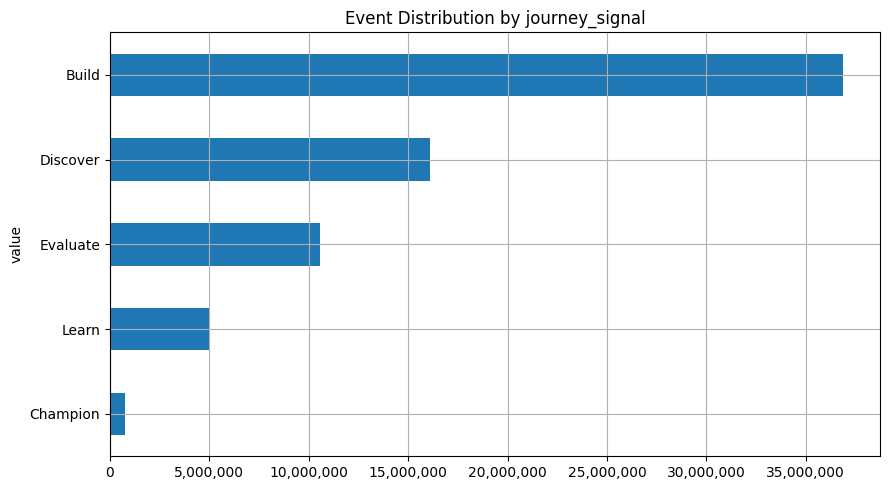

effort_level


,value,events,pct
0,High,39026031,56.28
1,Passive,15675324,22.60
2,Moderate,14646146,21.12


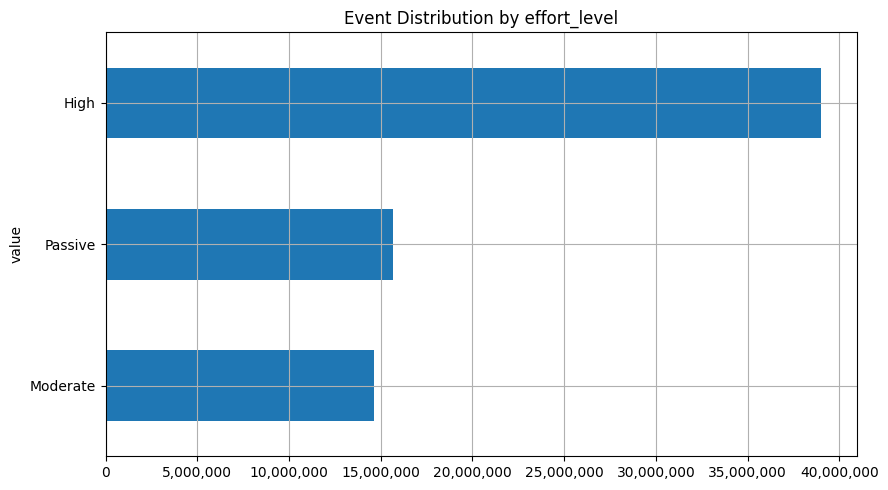

persona_hint


,value,events,pct
0,CUDA,25754824,37.14
1,Other,25562790,36.86
2,Robotics,12254776,17.67
3,GenAI,4112208,5.93
4,Simulation,930272,1.34
5,Learning_Community,732631,1.06


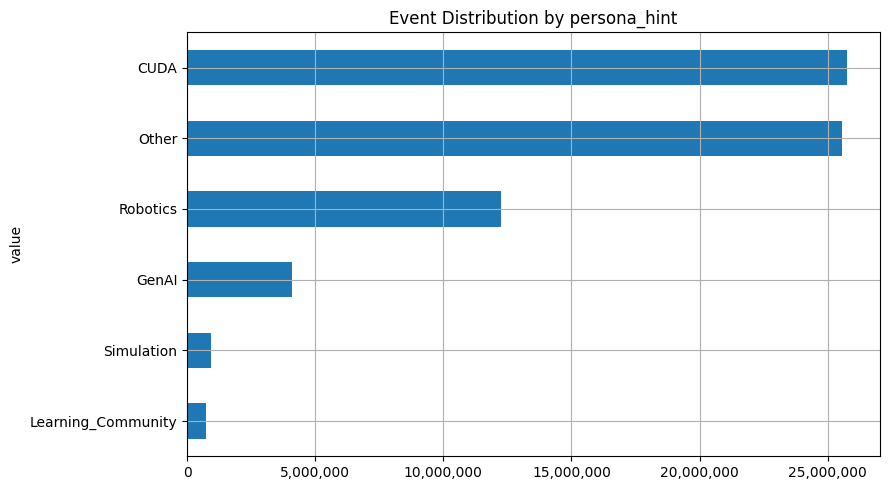

modality


,value,events,pct
0,Download,47462671,68.44
1,Content,16993171,24.50
2,Event,2051674,2.96
3,Training,1934108,2.79
4,Community,784056,1.13
5,Cloud Workspace,121821,0.18


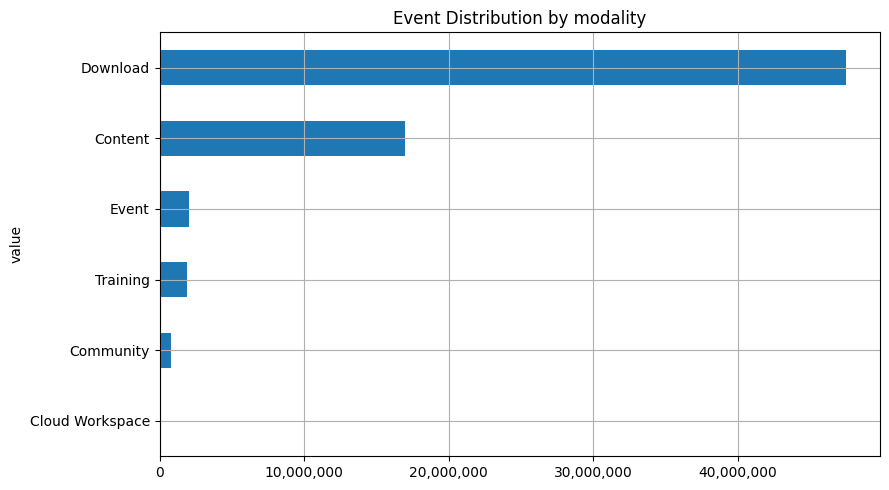

lead_source


,value,events,pct
0,unknown,57429863,82.81
1,gseo,4333091,6.25
2,website,3169388,4.57
3,ref,3067039,4.42
4,bseo,1041171,1.50
5,yseo,16295,0.02
6,nala_dev_wbn_202311_dl28_the fast path to deve...,12700,0.02
7,nala_dev_wbn_202311_dl28_tailoring llms to you...,8091,0.01
8,nala_dev_wbn_202311_dl28_running your own llm,6673,0.01
9,nala_dev_wbn_202401_dl31_fast-track to generat...,5115,0.01


In [27]:
if TABLES['activity_labeled']:
    tags=[c for c in ['journey_signal','effort_level','persona_hint','modality','lead_source'] if c in cols(TABLES['activity_labeled'])]
    for tag in tags:
        print(tag)
        tag_df=con.execute(f"""
            SELECT {tag} AS value, COUNT(*) AS events, ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),2) AS pct
            FROM {TABLES['activity_labeled']}
            GROUP BY 1
            ORDER BY events DESC
            LIMIT 30
        """).fetchdf()
        display(tag_df)
        if len(tag_df)<=20:
            ax=tag_df.sort_values('events').plot.barh(x='value',y='events',figsize=(9,5),legend=False)
            ax.set_title(f'Event Distribution by {tag}'); ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
            plt.tight_layout(); plt.show()

## 27. Marketing / Source Diagnostics
**Source:** Dom marketing touch vs self-directed activity section, updated for v2 fields.

,lead_source,events,developers,event_pct
0,unknown,57429863,5647334,82.81
1,gseo,4333091,1484109,6.25
2,website,3169388,1426115,4.57
3,ref,3067039,1513862,4.42
4,bseo,1041171,433954,1.50
5,yseo,16295,9224,0.02
6,nala_dev_wbn_202311_dl28_the fast path to deve...,12700,10955,0.02
7,nala_dev_wbn_202311_dl28_tailoring llms to you...,8091,7075,0.01
8,nala_dev_wbn_202311_dl28_running your own llm,6673,5922,0.01
9,nala_dev_wbn_202401_dl31_fast-track to generat...,5115,4558,0.01


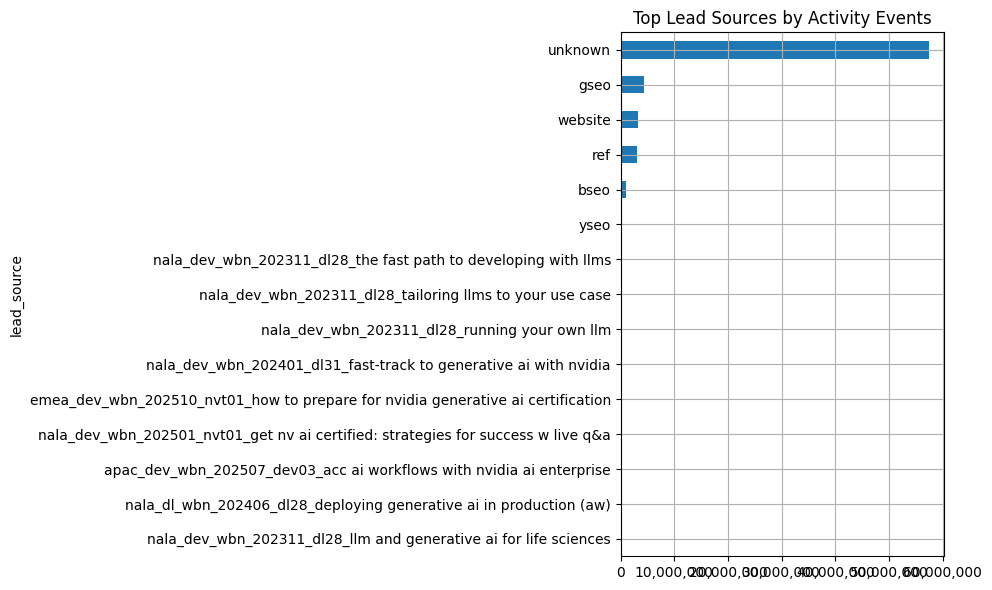

In [28]:
if TABLES['activity_labeled'] and 'lead_source' in cols(TABLES['activity_labeled']):
    lead=con.execute(f"""
        SELECT COALESCE(NULLIF(TRIM(lead_source), ''), 'unknown') AS lead_source,
               COUNT(*) AS events,
               COUNT(DISTINCT developer_id) AS developers,
               ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),2) AS event_pct
        FROM {TABLES['activity_labeled']}
        GROUP BY 1
        ORDER BY events DESC
        LIMIT 25
    """).fetchdf()
    display(lead)
    ax=lead.head(15).sort_values('events').plot.barh(x='lead_source',y='events',figsize=(10,6),legend=False)
    ax.set_title('Top Lead Sources by Activity Events'); ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    plt.tight_layout(); plt.show()

## 28. Modeling Readiness Matrix
**Source:** New final-production validation.

In [29]:
modeling_recs=pd.DataFrame([
 {'feature_group':'Raw count/rate/log features','use_for_modeling':'Yes','notes':'Primary modeling inputs. Prefer log and binary versions for zero-inflated features.'},
 {'feature_group':'behavior_journey_stage_30d','use_for_modeling':'Use carefully','notes':'Good for segmentation/reporting. Avoid if target is derived from same 0-30d window.'},
 {'feature_group':'current_journey_state_30d','use_for_modeling':'Usually no','notes':'Combined reporting label. It intentionally includes dormancy and behavior.'},
 {'feature_group':'dormancy_status','use_for_modeling':'Depends on target','notes':'Good for lifecycle analysis. Avoid leakage if predicting churn using current recency.'},
 {'feature_group':'persona','use_for_modeling':'Yes','notes':'Useful segment feature. Include confidence and entropy.'},
 {'feature_group':'contact metadata','use_for_modeling':'Use carefully','notes':'Good for enrichment. Watch missingness and demographic bias.'},
 {'feature_group':'activity_dictionary labels','use_for_modeling':'Yes','notes':'Dictionary is deterministic and production-safe.'},
])
display(modeling_recs)

,feature_group,use_for_modeling,notes
0,Raw count/rate/log features,Yes,Primary modeling inputs. Prefer log and binary...
1,behavior_journey_stage_30d,Use carefully,Good for segmentation/reporting. Avoid if targ...
2,current_journey_state_30d,Usually no,Combined reporting label. It intentionally inc...
3,dormancy_status,Depends on target,Good for lifecycle analysis. Avoid leakage if ...
4,persona,Yes,Useful segment feature. Include confidence and...
5,contact metadata,Use carefully,Good for enrichment. Watch missingness and dem...
6,activity_dictionary labels,Yes,Dictionary is deterministic and production-safe.


## 29. Executive Summary Outputs
**Source:** Tyler key findings summary, rewritten for final production features.

In [30]:
print('='*80)
print('FINAL FEATURE EDA EXECUTIVE SUMMARY')
print('='*80)
print(f'Total developers: {len(df):,}')
if 'is_activated' in df.columns:
    print(f"Activated developers: {int((df['is_activated']==1).sum()):,} ({100*(df['is_activated']==1).mean():.2f}%)")
if 'behavior_journey_stage_30d' in df.columns:
    print('\nBehavior journey distribution:')
    print(df['behavior_journey_stage_30d'].value_counts(normalize=True).mul(100).round(2))
if 'dormancy_status' in df.columns:
    print('\nDormancy distribution:')
    print(df['dormancy_status'].value_counts(normalize=True).mul(100).round(2))
if 'intent_signal' in df.columns:
    print('\nIntent distribution:')
    print(df['intent_signal'].value_counts(normalize=True).mul(100).round(2))
if 'persona' in df.columns:
    print('\nPersona distribution:')
    print(df['persona'].value_counts(normalize=True).mul(100).round(2).head(10))

FINAL FEATURE EDA EXECUTIVE SUMMARY
Total developers: 9,381,508
Activated developers: 7,660,278 (81.65%)

Behavior journey distribution:
behavior_journey_stage_30d
Historically_Active    74.04
Unactivated            18.35
Builder                 3.41
Learner                 2.88
Explorer                1.02
Evaluator               0.30
Name: proportion, dtype: float64

Dormancy distribution:
dormancy_status
Dormant        56.55
Unactivated    18.35
At_Risk        16.85
Active          4.46
Cooling         3.80
Name: proportion, dtype: float64

Persona distribution:
persona
CUDA                  37.52
GenAI                 24.67
Unknown               19.93
Robotics               6.30
Simulation             6.08
Learning_Community     5.50
Name: proportion, dtype: float64


## 30. Close Connection

In [31]:
con.close()
print('Done.')

Done.


## Lifecycle feature review

This section reviews the lifecycle columns now produced by `FeatureEngineering_v2_lifecycle_final.ipynb`. It does not recreate feature logic, so EDA stays separate from the feature pipeline.


In [32]:
# Lifecycle feature review for the final feature table.
# Run FeatureEngineering_v2_lifecycle_final.ipynb first so dev_profile_final_v4 exists.
import duckdb
import pandas as pd

con = duckdb.connect("developer_project.duckdb")

required_cols = con.execute("""
SELECT column_name
FROM information_schema.columns
WHERE table_name = 'dev_profile_final_v4'
  AND column_name IN ('user_type', 'max_stage_reached', 'final_lifecycle_status')
ORDER BY column_name
""").fetchdf()

print("Lifecycle columns available:")
display(required_cols)

print("User type distribution:")
display(con.execute("""
SELECT
    user_type,
    COUNT(*) AS developers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM dev_profile_final_v4
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())

print("Max stage reached distribution:")
display(con.execute("""
SELECT
    max_stage_reached,
    COUNT(*) AS developers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM dev_profile_final_v4
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())

print("Final lifecycle status distribution:")
display(con.execute("""
SELECT
    final_lifecycle_status,
    COUNT(*) AS developers,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM dev_profile_final_v4
GROUP BY 1
ORDER BY developers DESC
""").fetchdf())

print("Lifecycle status by persona:")
display(con.execute("""
SELECT
    persona,
    final_lifecycle_status,
    COUNT(*) AS developers
FROM dev_profile_final_v4
GROUP BY 1,2
ORDER BY developers DESC
LIMIT 40
""").fetchdf())

con.close()


Lifecycle columns available:


,column_name
0,final_lifecycle_status
1,max_stage_reached
2,user_type


User type distribution:


,user_type,developers,pct
0,tourist,4976445,53.05
1,real_user,4189544,44.66
2,free_email_user,215519,2.30


Max stage reached distribution:


,max_stage_reached,developers,pct
0,Build,2943869,31.38
1,Discover,2142834,22.84
2,None,1721230,18.35
3,Learn,1451967,15.48
4,Evaluate,1043427,11.12
5,Champion,78181,0.83


Final lifecycle status distribution:


,final_lifecycle_status,developers,pct
0,Tourist,4976445,53.05
1,Unactivated,1721230,18.35
2,Dormant_Build,1074499,11.45
3,Dormant_Learn,355840,3.79
4,AtRisk_Build,217300,2.32
5,FreeEmail,215519,2.30
6,Active_Build,203604,2.17
7,Active_Discover,139750,1.49
8,Dormant_Evaluate,122972,1.31
9,AtRisk_Learn,114390,1.22


Lifecycle status by persona:


,persona,final_lifecycle_status,developers
0,CUDA,Tourist,1941433
1,GenAI,Tourist,1565655
2,Unknown,Unactivated,1293261
3,CUDA,Dormant_Build,844395
4,Unknown,Tourist,494277
5,Simulation,Tourist,375652
6,Learning_Community,Tourist,332260
7,GenAI,Unactivated,283810
8,Robotics,Tourist,267168
9,CUDA,AtRisk_Build,145811
